# Bayesian Optimization

Imagine you need to find the best settings for a complex system – perhaps tuning the hyperparameters of a deep learning model, optimizing the design of an experiment, or finding the ideal parameters for a simulation. Often, evaluating the system with a given set of parameters (i.e., running the experiment or training the model) is expensive, time-consuming, or resource-intensive. How can you find the optimal settings without performing an exhaustive search?

This is where **Bayesian Optimization (BO)** comes in. It's a powerful, sequential strategy designed specifically for the **global optimization of black-box functions**. These are functions where:

1.  We don't know the underlying mathematical form (it's a "black box").
2.  Evaluating the function (getting an output `y` for an input `x`) is costly.
3.  We often cannot compute derivatives (gradients).
4.  The observations might be noisy (the output `y` can vary even for the same input `x`).

BO tackles this challenge by intelligently choosing the next point to evaluate, aiming to find the optimum (maximum or minimum) in as few evaluations as possible.

### Core Components

Bayesian Optimization cleverly balances exploring unknown parts of the search space and exploiting areas known to yield good results. It does this using two main components:

1.  **A Probabilistic Surrogate Model:** This model approximates the unknown objective function based on the points observed so far. It also provides uncertainty estimates about the function's behavior in unexplored regions. Gaussian Processes (GPs) are the most common choice for this surrogate model due to their flexibility and inherent uncertainty quantification.
2.  **An Acquisition Function:** This function uses the surrogate model's predictions (mean and uncertainty) to determine the 'utility' of evaluating any given point in the search space. It guides the search by suggesting the point that is most likely to lead to an improvement, considering both the predicted performance and the uncertainty. Examples include Expected Improvement (EI) and Upper Confidence Bound (UCB).

### The Iterative Process

The BO algorithm works iteratively:

1.  **Observe:** Evaluate the black-box function at one or more points chosen by the acquisition function.
2.  **Update:** Update the surrogate model (e.g., the Gaussian Process) using all the data collected so far (inputs and their observed outputs).
3.  **Select:** Optimize the acquisition function (which is cheap to evaluate) over the search space to find the most promising point(s) to evaluate next.
4.  **Repeat:** Continue this cycle until a stopping criterion is met (e.g., budget of function evaluations exhausted, desired performance level reached).


### Recommended reading:

1. [A Tutorial on Bayesian Optimization](https://arxiv.org/pdf/1807.02811)
1. [BayesOpt docs](<(https://bayesian-optimization.github.io/BayesianOptimization/2.0.3/)>)
1. [Exploring Bayesian Optimization](https://distill.pub/2020/bayesian-optimization/)
1. [Acquisition functions in Bayesian Optimization](https://ekamperi.github.io/machine%20learning/2021/06/11/acquisition-functions.html)
1. [A Visual Exploration of Gaussian Processes](https://distill.pub/2019/visual-exploration-gaussian-processes/)
1. [Practical Bayesian Optimization of Machine Learning Algorithms](https://arxiv.org/abs/1206.2944)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from bayes_opt import BayesianOptimization
from bayes_opt import acquisition

# Set random seed for reproducibility
np.random.seed(42)

### Define and visualize the target function

First, we'll create a synthetic objective function to optimize. This specific function has three peaks (at x=0, x≈2 and x≈6) and is a toy example.

$$f(x) = e^{-(x - 2)^2} + e^{-\frac{(x - 6)^2}{10}} + \frac{1}{x^2 + 1}$$


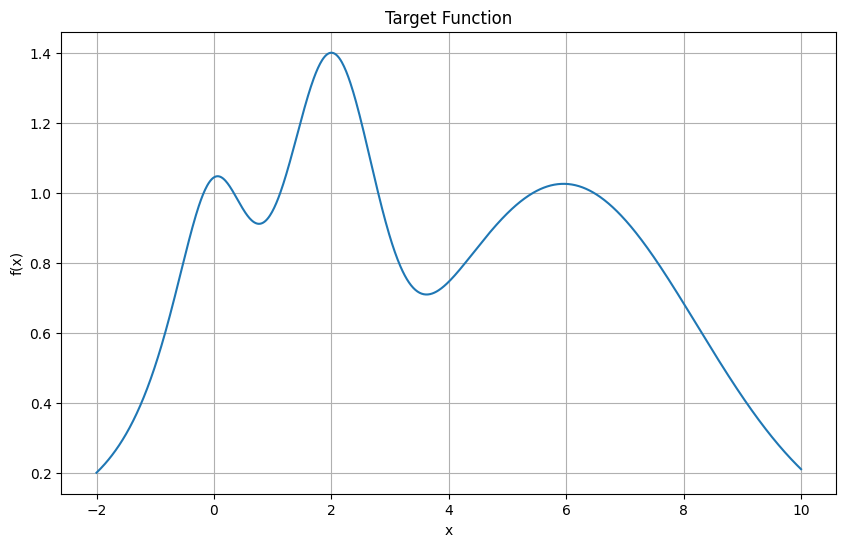

In [3]:
def target_function(x):
    """Our example target function to be optimized"""
    return np.exp(-((x - 2) ** 2)) + np.exp(-((x - 6) ** 2) / 10) + 1 / (x**2 + 1)


x = np.linspace(-2, 10, 1000)
y = target_function(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.grid(True)
plt.title("Target Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

### Define visualization functions

These helper functions will visualize the Gaussian Process model
and acquisition function at each step of the optimization process.
They help us understand how the model evolves as more observations are made.


In [ ]:
def posterior(optimizer, grid):
    """Get posterior mean and standard deviation from GP model"""
    mu, sigma = optimizer._gp.predict(grid, return_std=True)
    return mu, sigma


def plot_gp(optimizer, x, y, save_path=None):
    """Plot the Gaussian Process model, observations, and acquisition function"""
    fig = plt.figure(figsize=(16, 10))
    steps = len(optimizer.space)
    fig.suptitle(
        f"Gaussian Process and Utility Function After {steps} Steps",
        fontsize=30,
    )

    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1])
    axis = plt.subplot(gs[0])
    acq = plt.subplot(gs[1])

    x_obs = np.array([[res["params"]["x"]] for res in optimizer.res])
    y_obs = np.array([res["target"] for res in optimizer.res])

    optimizer.acquisition_function._fit_gp(optimizer._gp, optimizer._space)
    mu, sigma = posterior(optimizer, x)

    axis.plot(x, y, linewidth=3, label="Target")
    axis.plot(
        x_obs.flatten(), y_obs, "D", markersize=8, label="Observations", color="r"
    )
    axis.plot(x, mu, "--", color="k", label="Prediction")

    axis.fill(
        np.concatenate([x, x[::-1]]),
        np.concatenate([mu - 1.9600 * sigma, (mu + 1.9600 * sigma)[::-1]]),
        alpha=0.6,
        fc="c",
        ec="None",
        label="95% confidence interval",
    )

    axis.set_xlim((-2, 10))
    axis.set_ylim((None, None))
    axis.set_ylabel("f(x)", fontdict={"size": 20})
    axis.set_xlabel("x", fontdict={"size": 20})

    utility_function = optimizer.acquisition_function
    utility = -1 * utility_function._get_acq(gp=optimizer._gp)(x)
    x_flat = x.flatten()

    acq.plot(x_flat, utility, label="Utility Function", color="purple")
    acq.plot(
        x_flat[np.argmax(utility)],
        np.max(utility),
        "*",
        markersize=15,
        label="Next Best Guess",
        markerfacecolor="gold",
        markeredgecolor="k",
        markeredgewidth=1,
    )
    acq.set_xlim((-2, 10))
    acq.set_ylabel("Utility", fontdict={"size": 20})
    acq.set_xlabel("x", fontdict={"size": 20})

    axis.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.0)
    acq.legend(loc=2, bbox_to_anchor=(1.01, 1), borderaxespad=0.0)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path)
        plt.close()
    else:
        plt.show()

    return fig

We'll now see Bayesian Optimization in action, step by step.
At each step, observe:

1. How the GP model (dashed line) is updated
2. How the confidence interval (light blue area) changes
3. How the acquisition function (purple line) guides the next sample
4. Where the next sample point (gold star) is placed


|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8198    | 3.109     |
| 2         | 0.746     | 7.775     |

Step 0: Initial random points


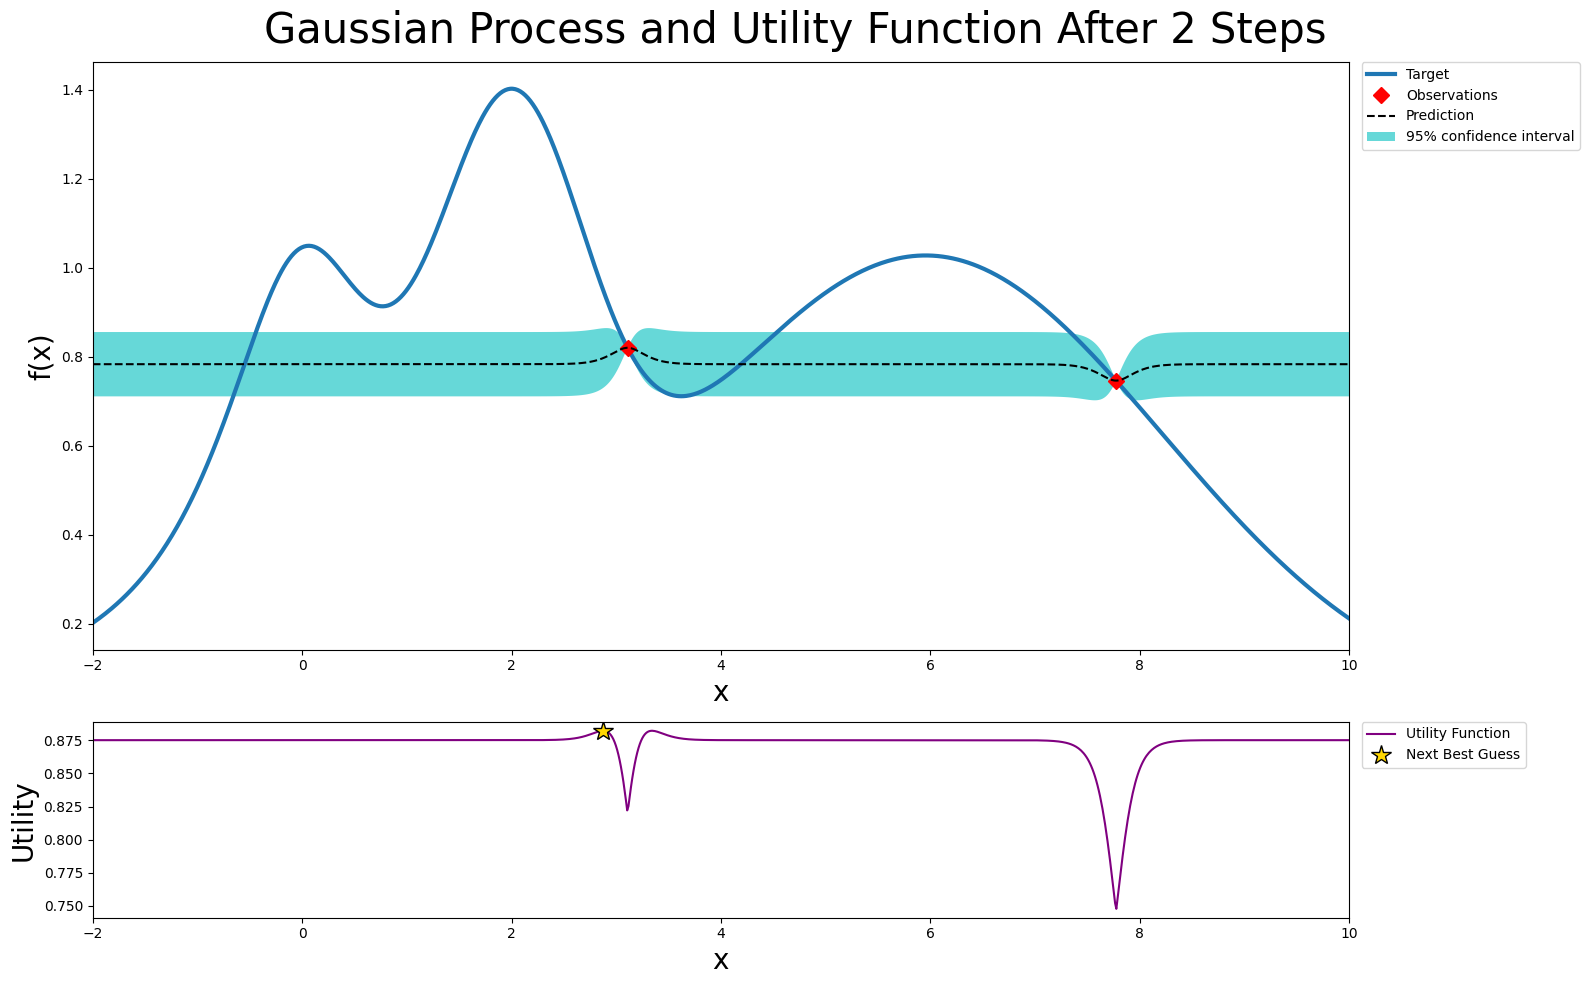

|   iter    |  target   |     x     |
-------------------------------------
| 3         | 0.9269    | 6.989     |

Step 1: Added a new observation


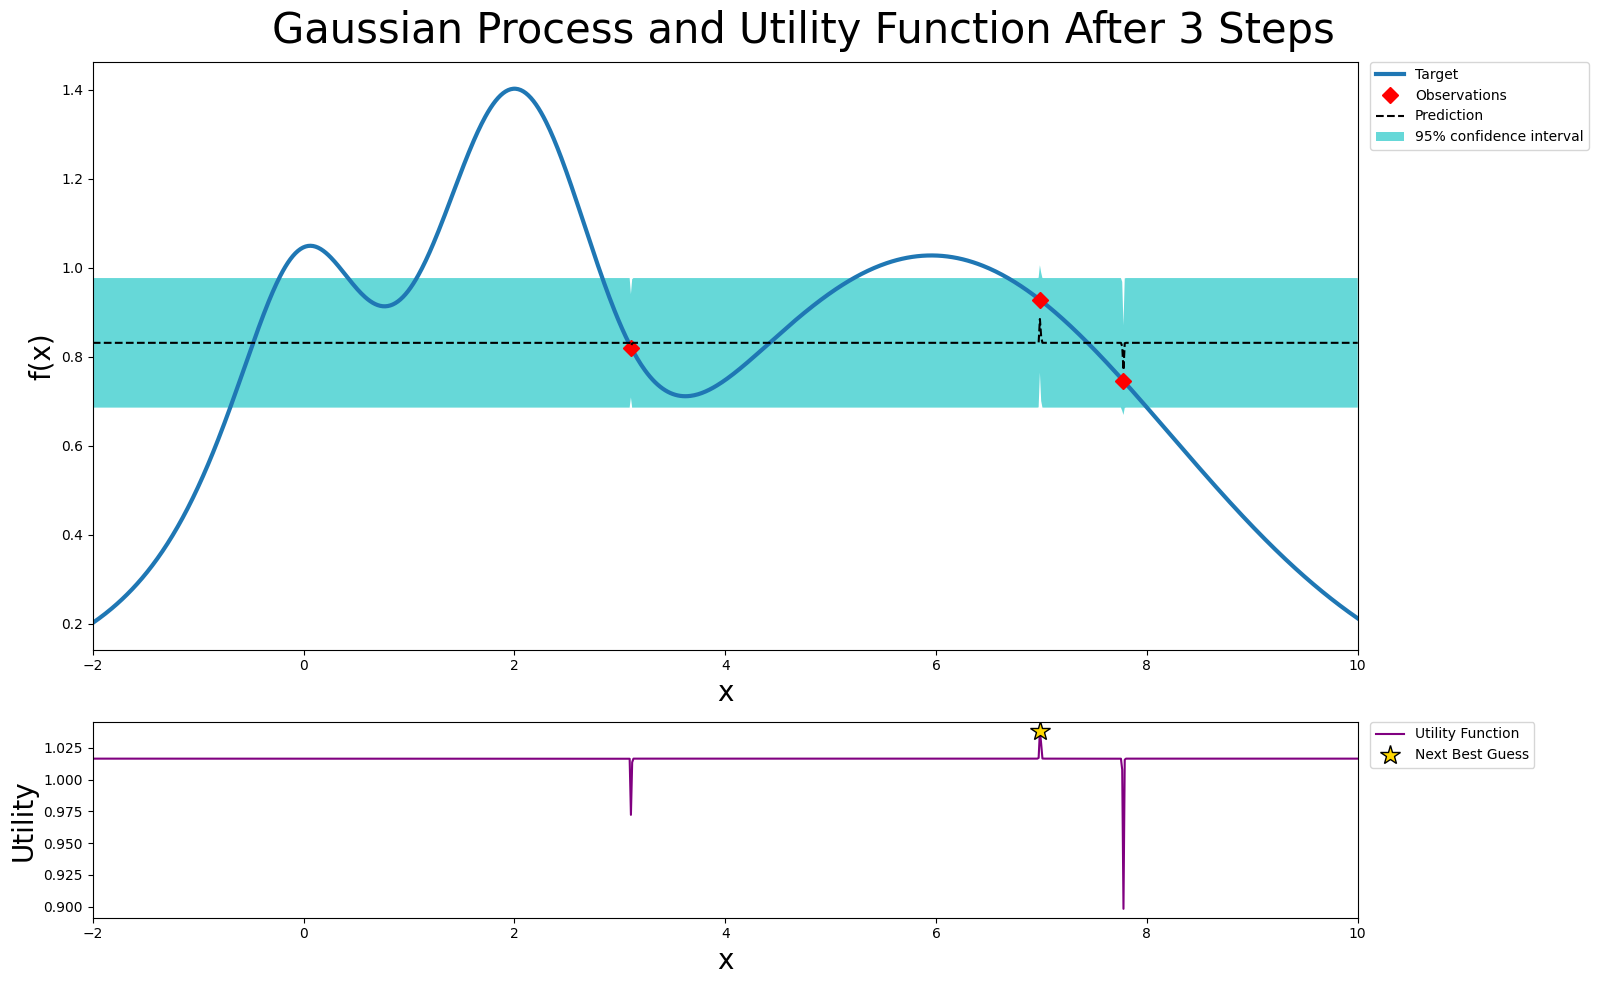

|   iter    |  target   |     x     |
-------------------------------------
| 4         | 0.9277    | 6.984     |

Step 2: Added a new observation


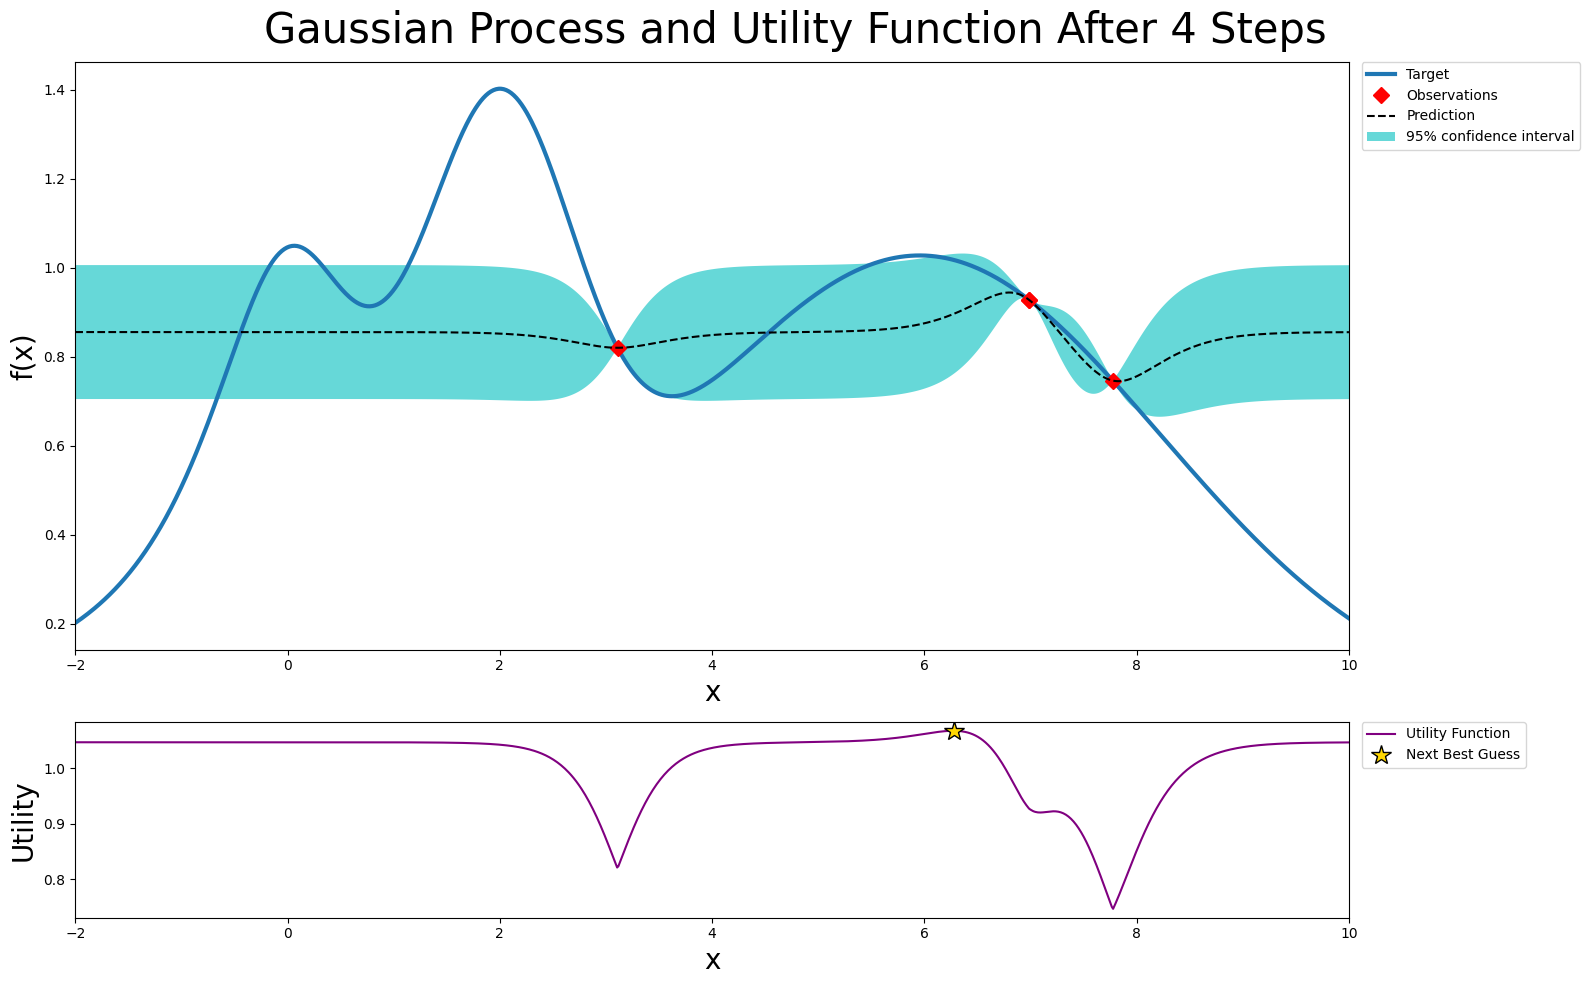

|   iter    |  target   |     x     |
-------------------------------------
| 5         | 1.017     | 6.273     |

Step 3: Added a new observation


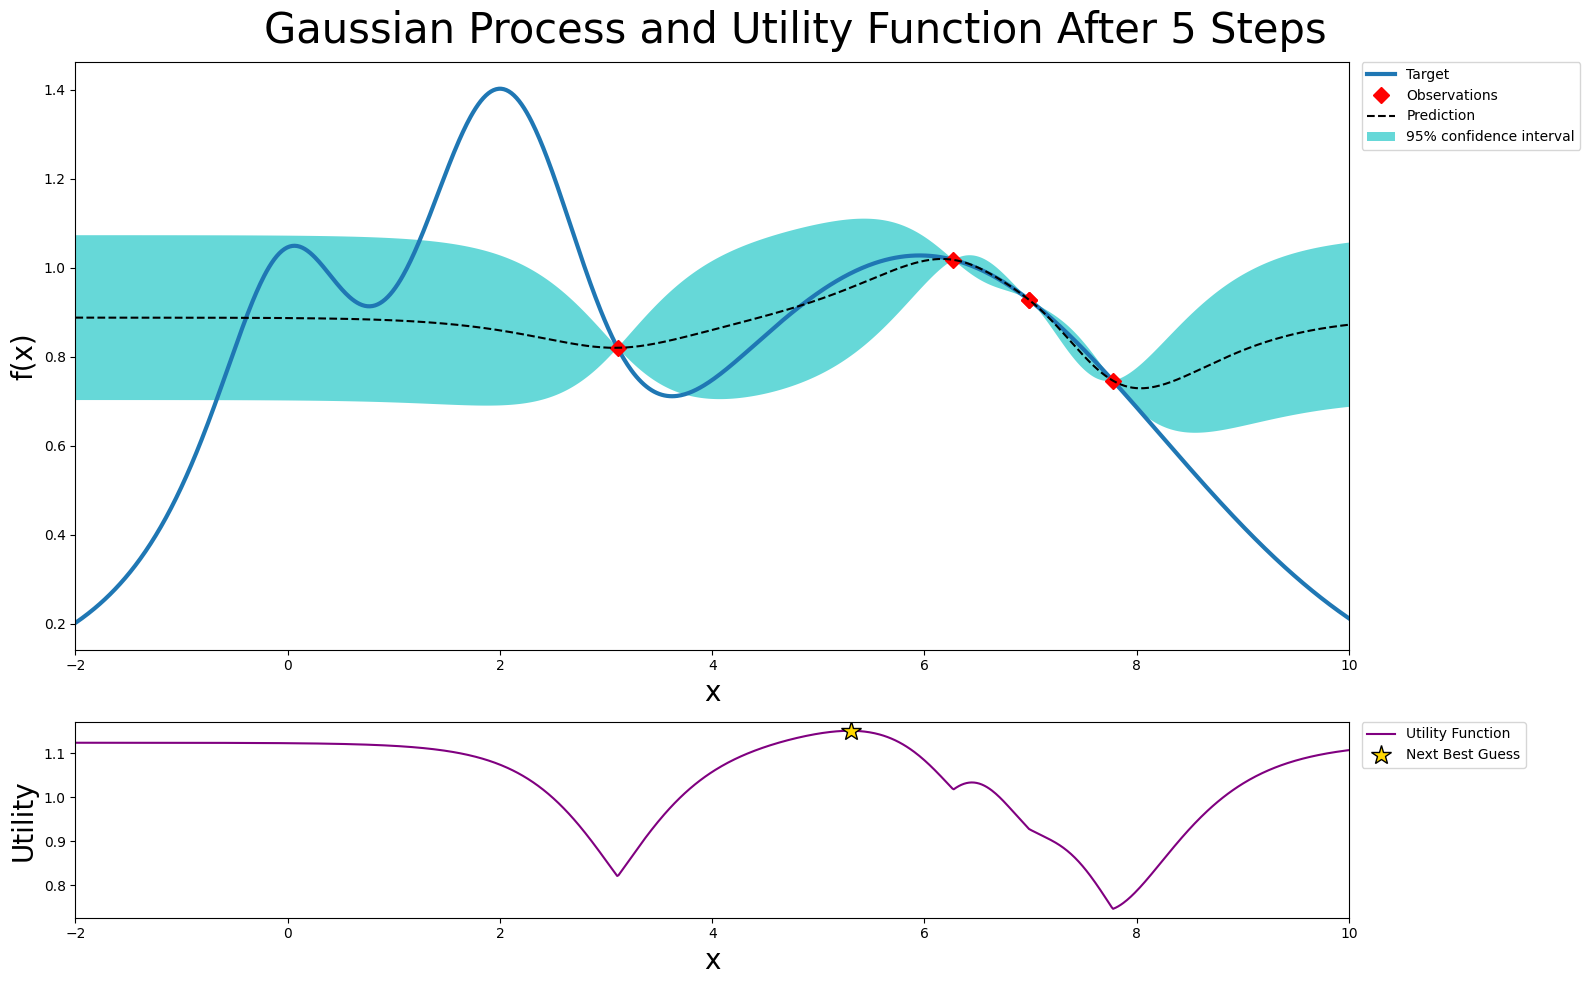

|   iter    |  target   |     x     |
-------------------------------------
| 6         | 0.9864    | 5.298     |

Step 4: Added a new observation


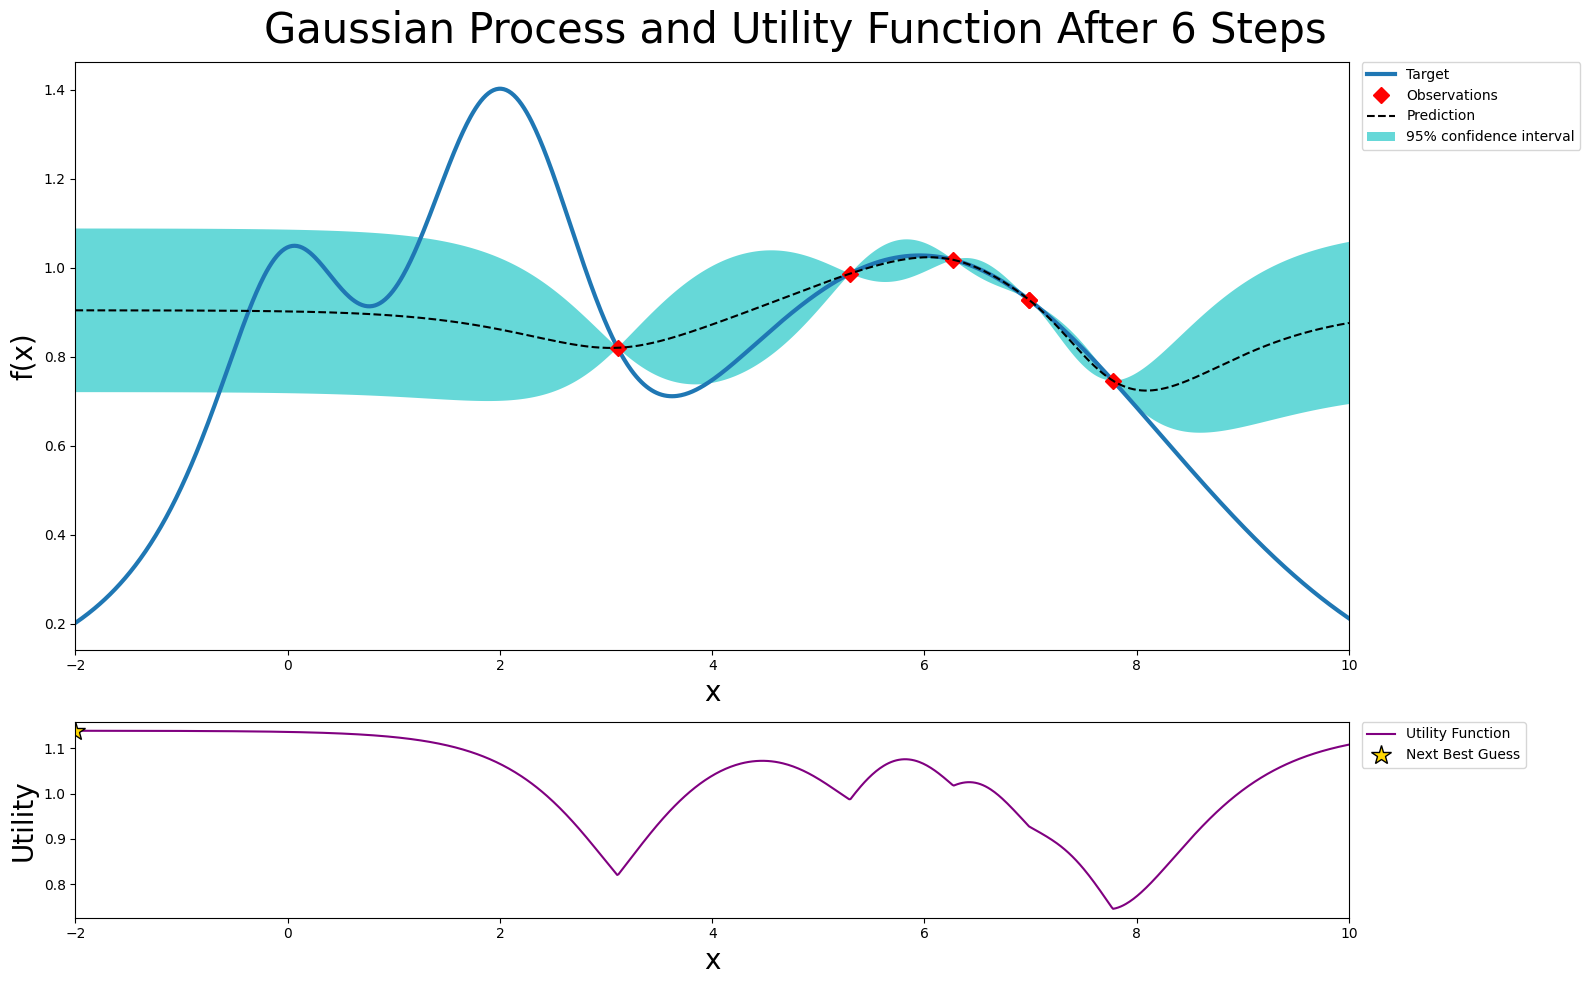

|   iter    |  target   |     x     |
-------------------------------------
| 7         | 0.2024    | -1.996    |

Step 5: Added a new observation


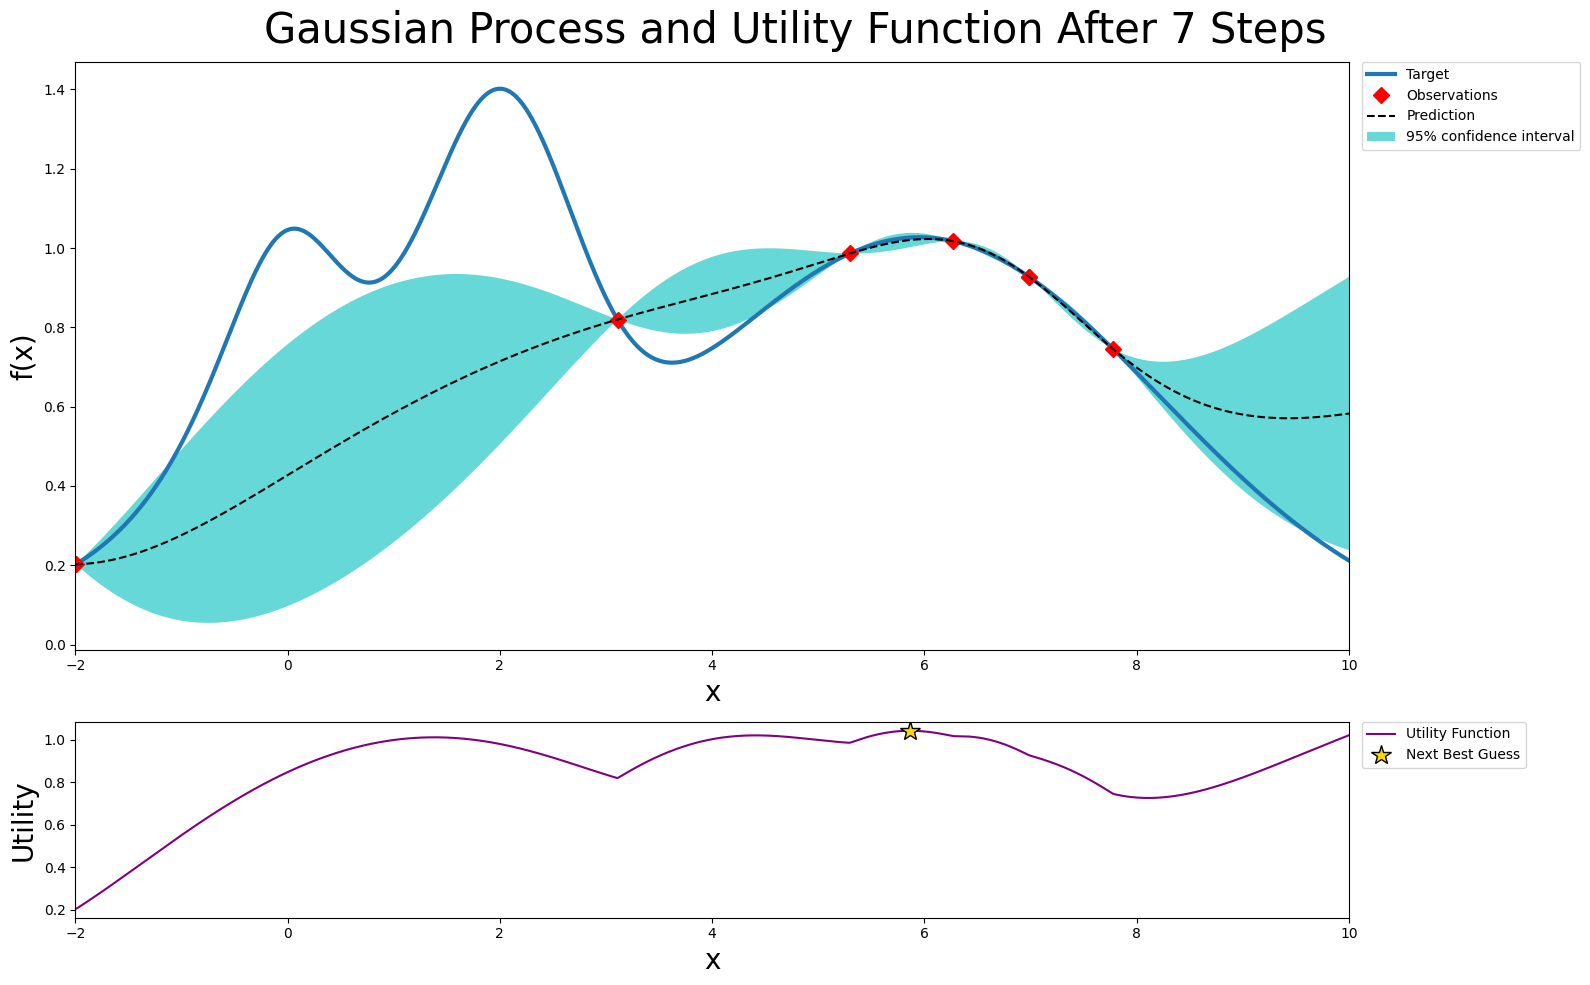


Final result:
Best target value found: 1.0174
Best input value found: x = 6.2727


In [5]:
acquisition_function = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=acquisition_function,
    random_state=27,
)

# Prepare data for visualization
x = np.linspace(-2, 10, 1000).reshape(-1, 1)
y = target_function(x)

# Initialize with 2 random points
optimizer.maximize(init_points=2, n_iter=0)
print("\nStep 0: Initial random points")
plot_gp(optimizer, x, y)

for i in range(1, 6):
    optimizer.maximize(init_points=0, n_iter=1)
    print(f"\nStep {i}: Added a new observation")
    plot_gp(optimizer, x, y)

print("\nFinal result:")
print(f"Best target value found: {optimizer.max['target']:.4f}")
print(f"Best input value found: x = {optimizer.max['params']['x']:.4f}")

Acquisition functions guide the sampling process by balancing:

- Exploitation: Sampling where the model predicts high values
- Exploration: Sampling where the model is uncertain

We'll compare three different acquisition functions:

1. Upper Confidence Bound (UCB): Balances exploration and exploitation
2. Probability of Improvement (PI): More exploitative
3. Greedy: Purely exploitative (custom implementation)


In [6]:
class GreedyAcquisition(acquisition.AcquisitionFunction):
    """Purely exploitative acquisition function (only considers mean)"""

    def __init__(self, random_state=None):
        super().__init__(random_state)

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        return mean  # disregard std

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8198    | 3.109     |
| 2         | 0.746     | 7.775     |
| 3         | 0.9496    | 2.875     |
| 4         | 0.5408    | 8.53      |
| 5         | 0.9495    | 2.875     |
| 6         | 1.249     | 2.44      |
| 7         | 1.388     | 1.872     |

UCB Acquisition Function Results:


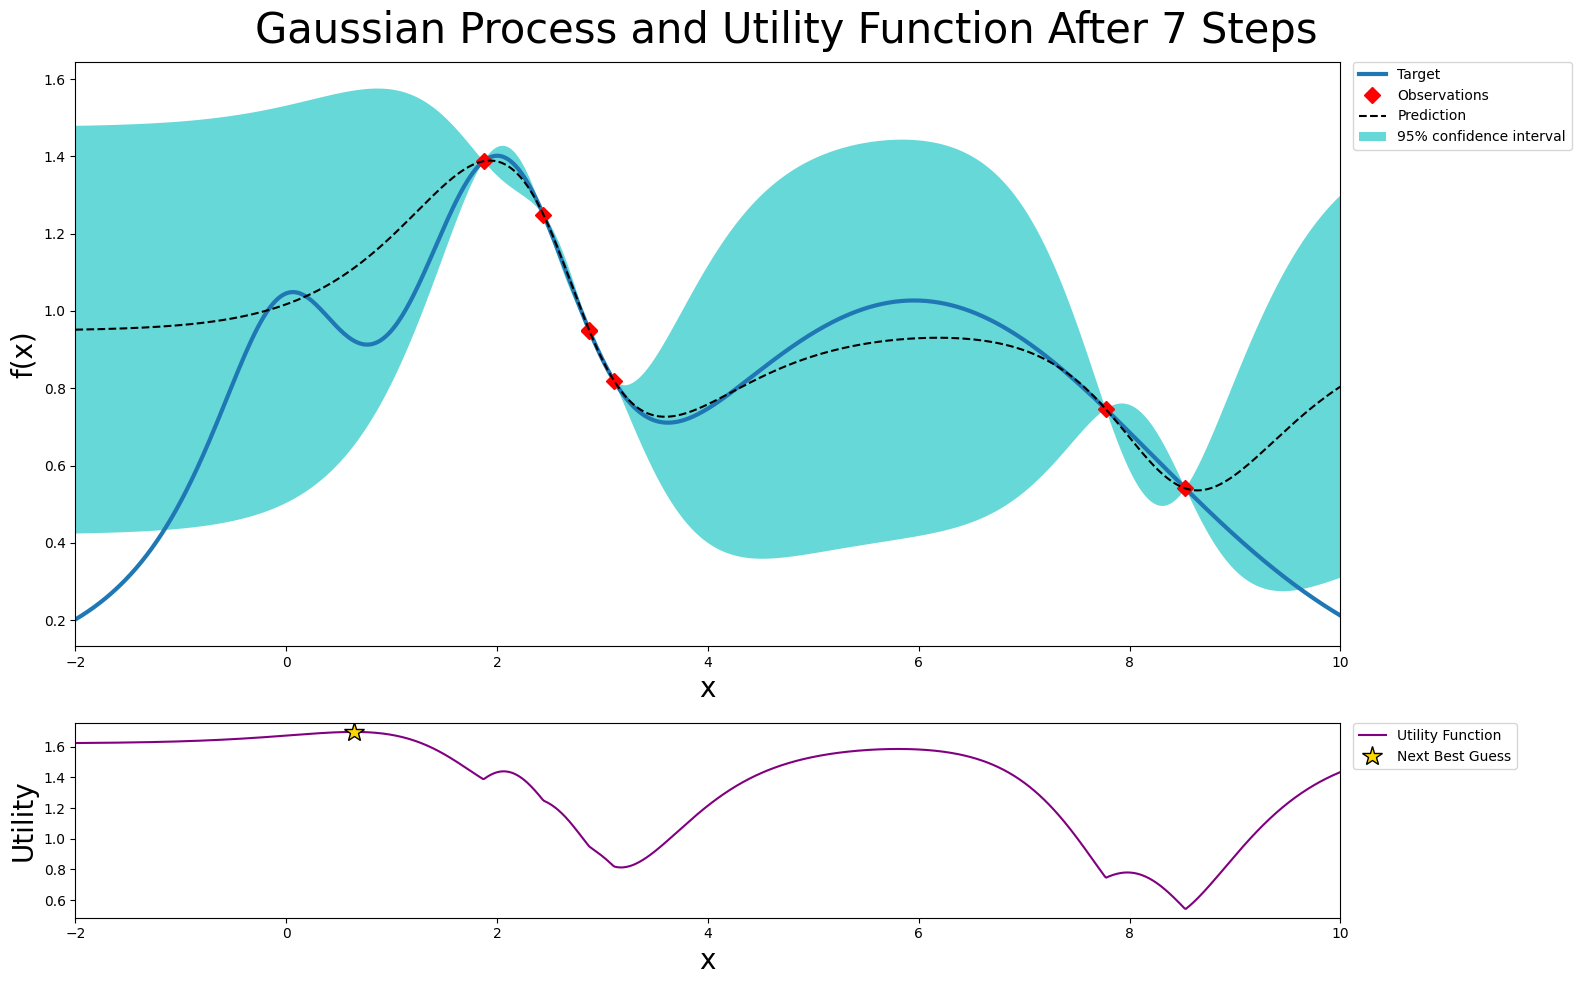

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8198    | 3.109     |
| 2         | 0.746     | 7.775     |
| 3         | 0.8245    | 3.098     |
| 4         | 0.8247    | 3.098     |
| 5         | 0.8261    | 3.095     |
| 6         | 0.8289    | 3.089     |
| 7         | 0.8382    | 3.069     |

Probability of Improvement Acquisition Function Results:


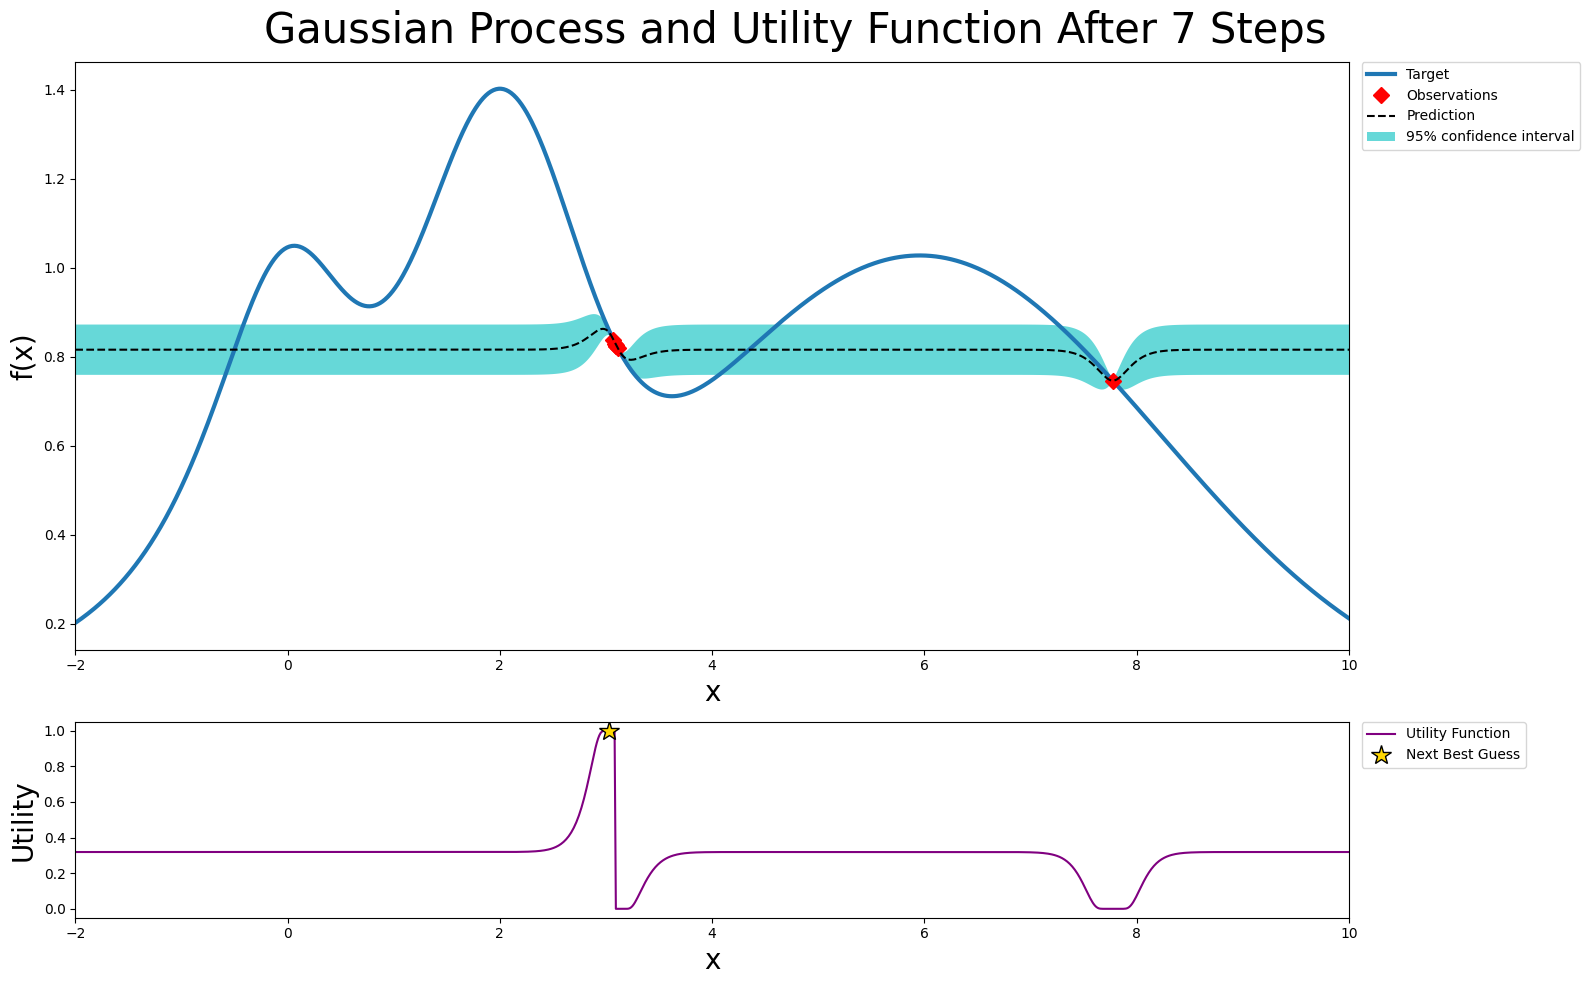

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8198    | 3.109     |
| 2         | 0.746     | 7.775     |
| 3         | 0.8189    | 3.111     |
| 4         | 0.8411    | 3.064     |
| 5         | 0.8775    | 2.995     |
| 6         | 0.9301    | 2.906     |
| 7         | 1.004     | 2.794     |

Greedy (Purely Exploitative) Acquisition Function Results:


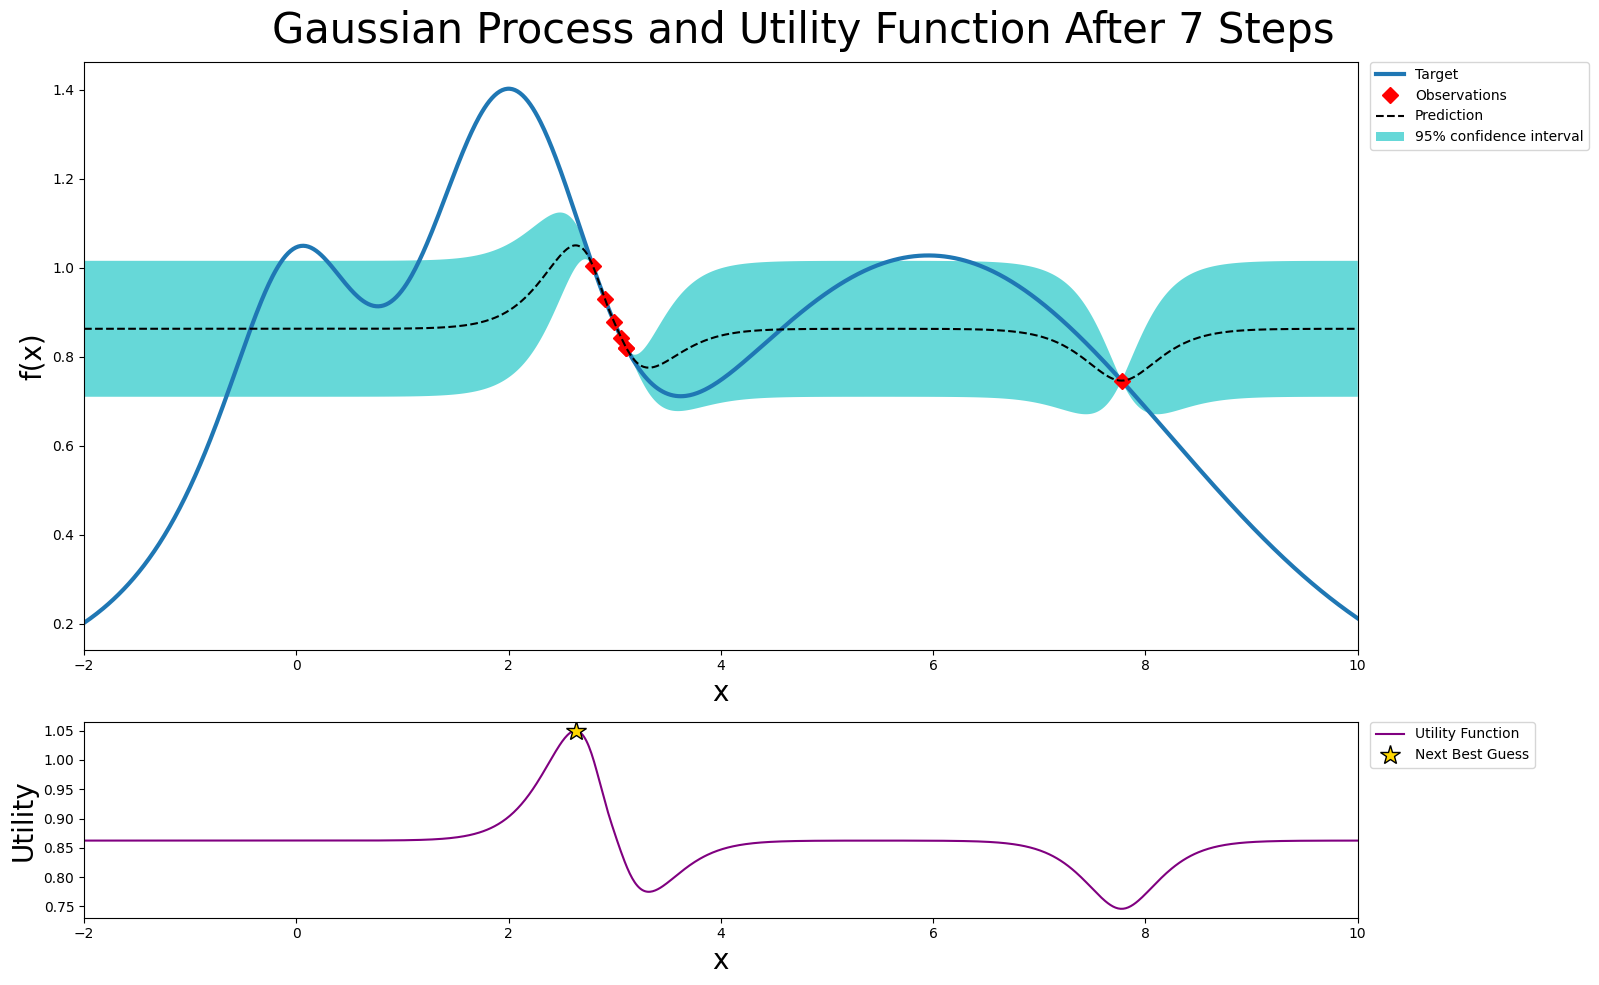


Summary of results:
UCB best value: 1.3878 at x = 1.8723
PI best value: 0.8382 at x = 3.0695
Greedy best value: 1.0038 at x = 2.7939


In [20]:
ucb = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

optimizer_ucb.maximize(init_points=2, n_iter=5)
print("\nUCB Acquisition Function Results:")
plot_gp(optimizer_ucb, x, y)

# Run with PI
pi = acquisition.ProbabilityOfImprovement(xi=1e-4)
optimizer_pi = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=pi,
    random_state=27,
)

optimizer_pi.maximize(init_points=2, n_iter=5)
print("\nProbability of Improvement Acquisition Function Results:")
plot_gp(optimizer_pi, x, y)

# Run with Greedy
greedy = GreedyAcquisition()
optimizer_greedy = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=greedy,
    random_state=27,
)

optimizer_greedy.maximize(init_points=2, n_iter=5)
print("\nGreedy (Purely Exploitative) Acquisition Function Results:")
plot_gp(optimizer_greedy, x, y)

# Summary
print("\nSummary of results:")
print(
    f"UCB best value: {optimizer_ucb.max['target']:.4f} at x = {optimizer_ucb.max['params']['x']:.4f}"
)
print(
    f"PI best value: {optimizer_pi.max['target']:.4f} at x = {optimizer_pi.max['params']['x']:.4f}"
)
print(
    f"Greedy best value: {optimizer_greedy.max['target']:.4f} at x = {optimizer_greedy.max['params']['x']:.4f}"
)

Comment these results. Write your observations in a Markdown cell.


The function that did the best is UCB. We can see that it explored the widest range of our target function and resulted in the best fit after 7 steps.
PI did not explore the area at all and all the samples were made around the initial 2 points.
Interestingly, purely greedy acquisition function explored wider area than PI and slightly more fitted to the target function. Also, the grapgh of the greedy function looks more smooth than the PI one


## Exercise 1: UCB

The parameter kappa in the UCB acquisition function controls the trade-off between:

- Exploration (high kappa): More emphasis on the uncertainty
- Exploitation (low kappa): More emphasis on the predicted mean

Compare results for UCB using 3 different values:

1. kappa = 0.1 (Mostly exploitation)
2. kappa = 2.5 (Balanced)
3. kappa = 5.0 (Mostly exploration)

Review this [blog post](https://ekamperi.github.io/machine%20learning/2021/06/11/acquisition-functions.html) and explain the underlying concept of UCB in a Markdown cell.


Upper confidence bound contains exploitation μ(x) and exploration σ(x) terms. <br>
The function can be denoted as a(x;λ)=μ(x)+λσ(x) <br>
UCB is a weighted sum of the expected performance captured by μ(x) of the Gaussian Process, and of the uncertainty σ(x), captured by the standard deviation of the GP.<br>
In UCB, we tune the exploitation vs exploration tradeoff by the paramter λ which tells us how much we favor exploration, because it gives bonus for high standard deviation. <br>
When λ is small, BO will favor solutions that are expected to be high-performing, i.e., have high μ(x). On the contrary, when λ is large, BO rewards the exploration of currently uncharted areas in the search space.


|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8198    | 3.109     |
| 2         | 0.746     | 7.775     |
| 3         | 0.8134    | 3.123     |
| 4         | 0.8196    | 3.109     |
| 5         | 0.8481    | 3.05      |
| 6         | 0.88      | 2.99      |
| 7         | 0.928     | 2.909     |
| 8         | 1.008     | 2.787     |

UCB Acquisition Function Results:


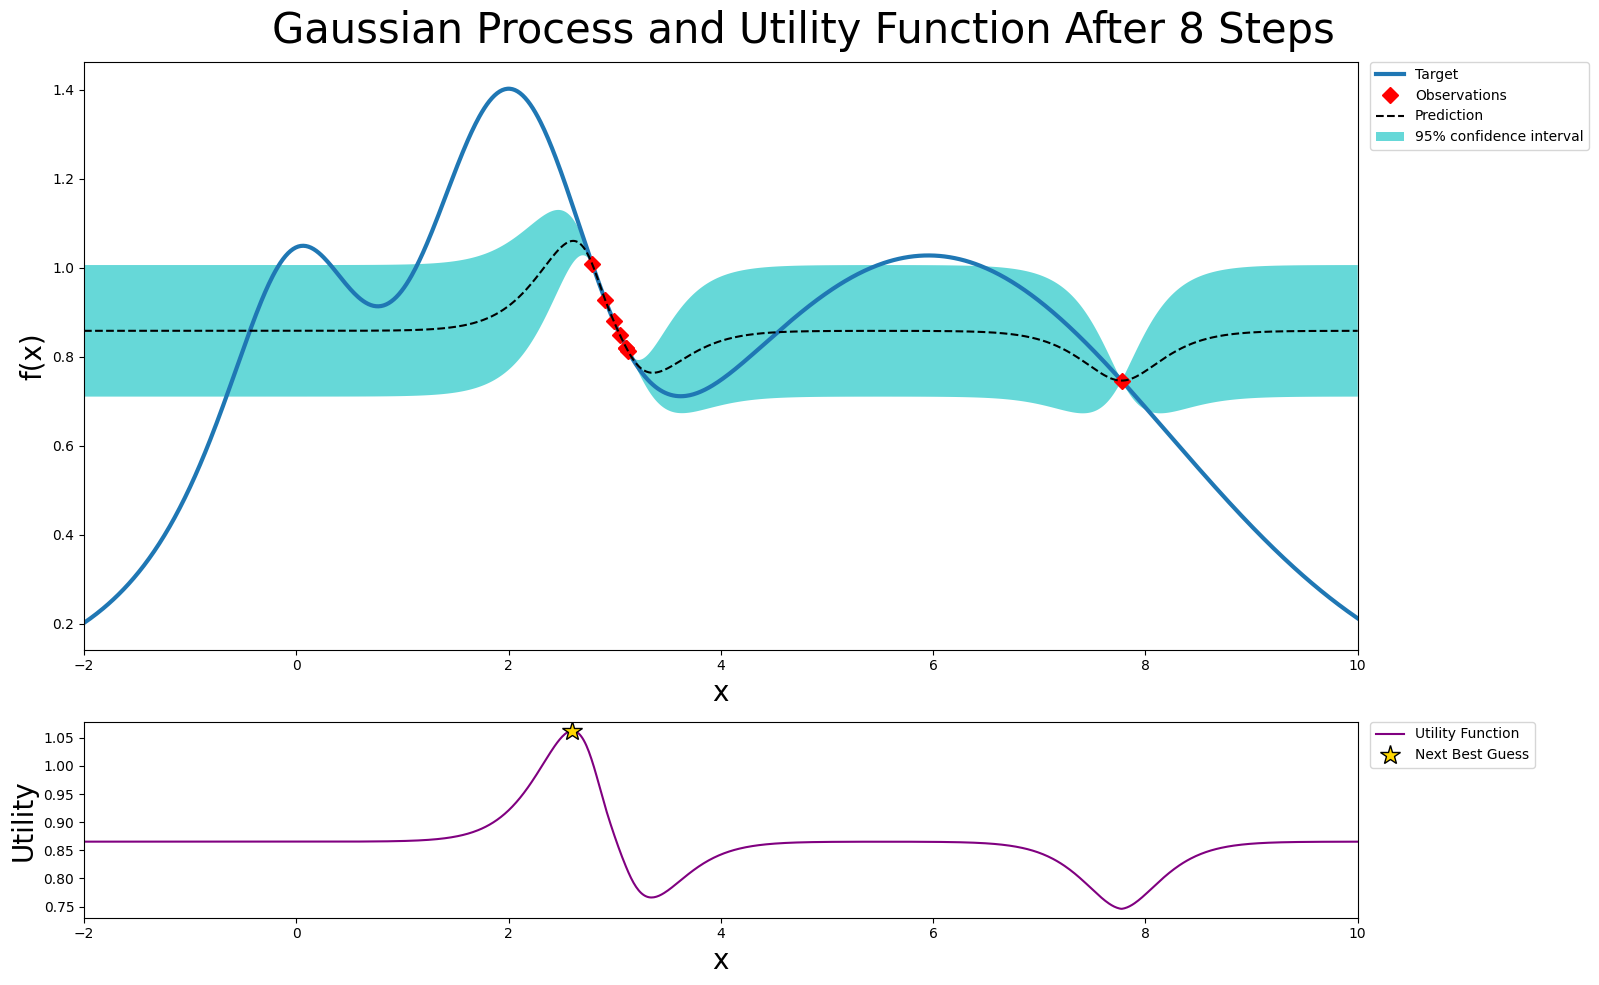

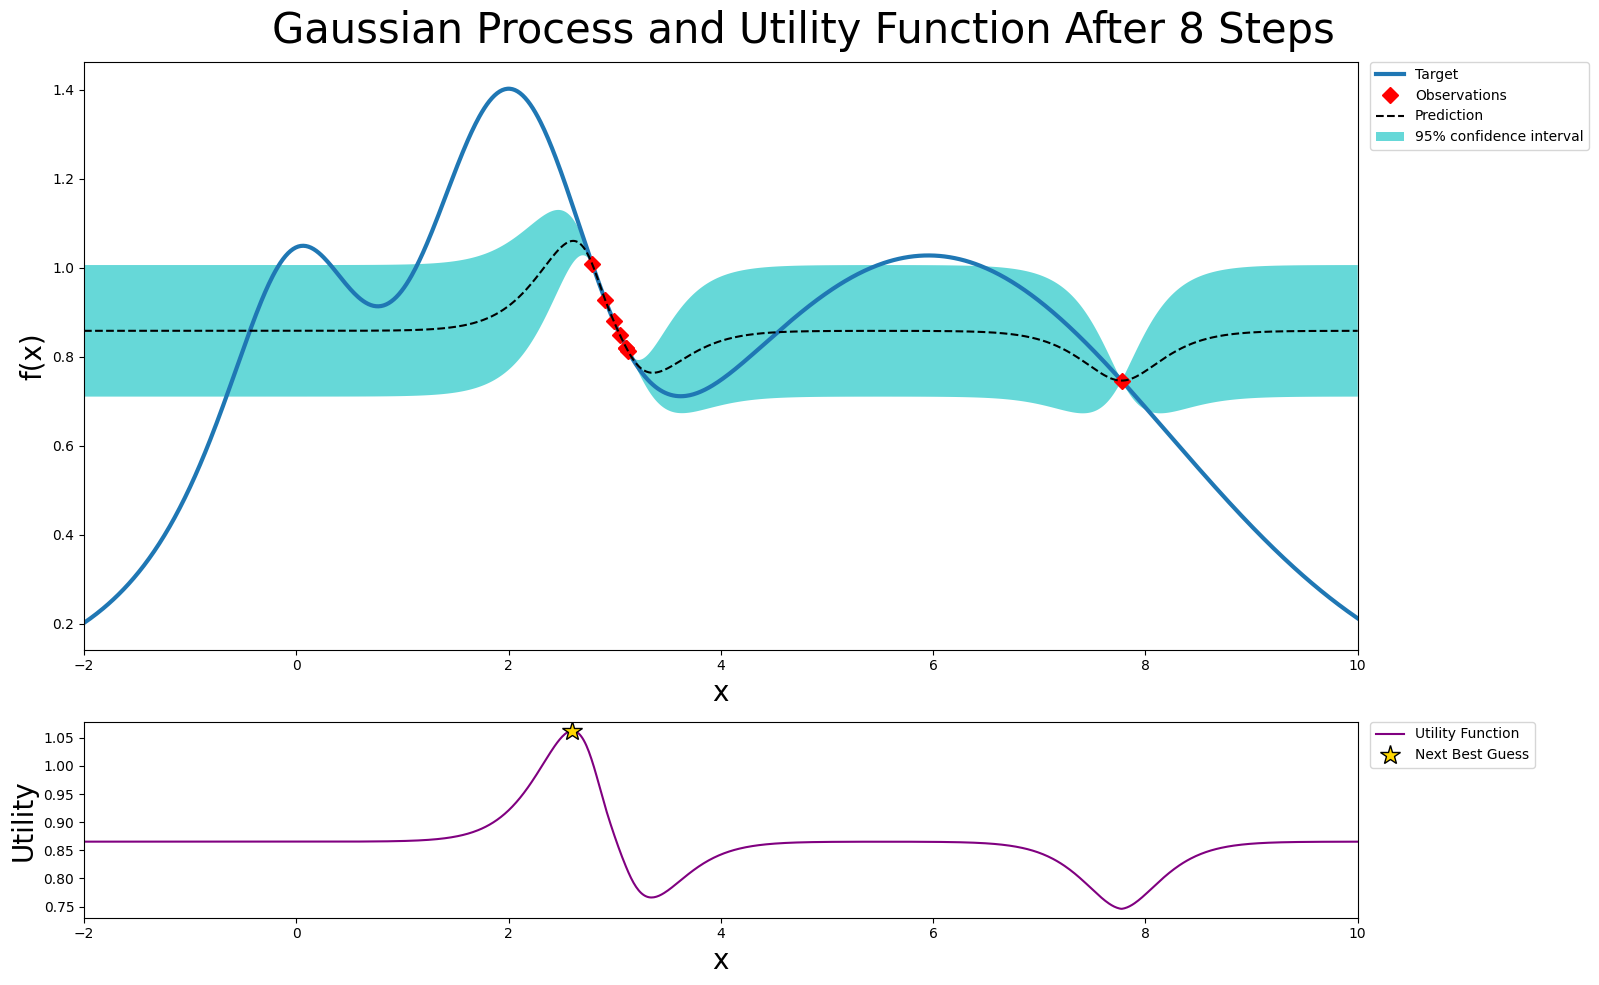

In [13]:
exploitation_ucb = acquisition.UpperConfidenceBound(kappa=0.1)
exploitation_optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=exploitation_ucb,
    random_state=27,
)

exploitation_optimizer_ucb.maximize(init_points=2, n_iter=6)
print("\nUCB Acquisition Function Results:")
plot_gp(exploitation_optimizer_ucb, x, y)

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8198    | 3.109     |
| 2         | 0.746     | 7.775     |
| 3         | 0.8265    | 3.094     |
| 4         | 0.8261    | 3.095     |
| 5         | 0.8666    | 3.014     |
| 6         | 0.9058    | 2.945     |
| 7         | 0.962     | 2.856     |
| 8         | 1.057     | 2.718     |

UCB Acquisition Function Results:


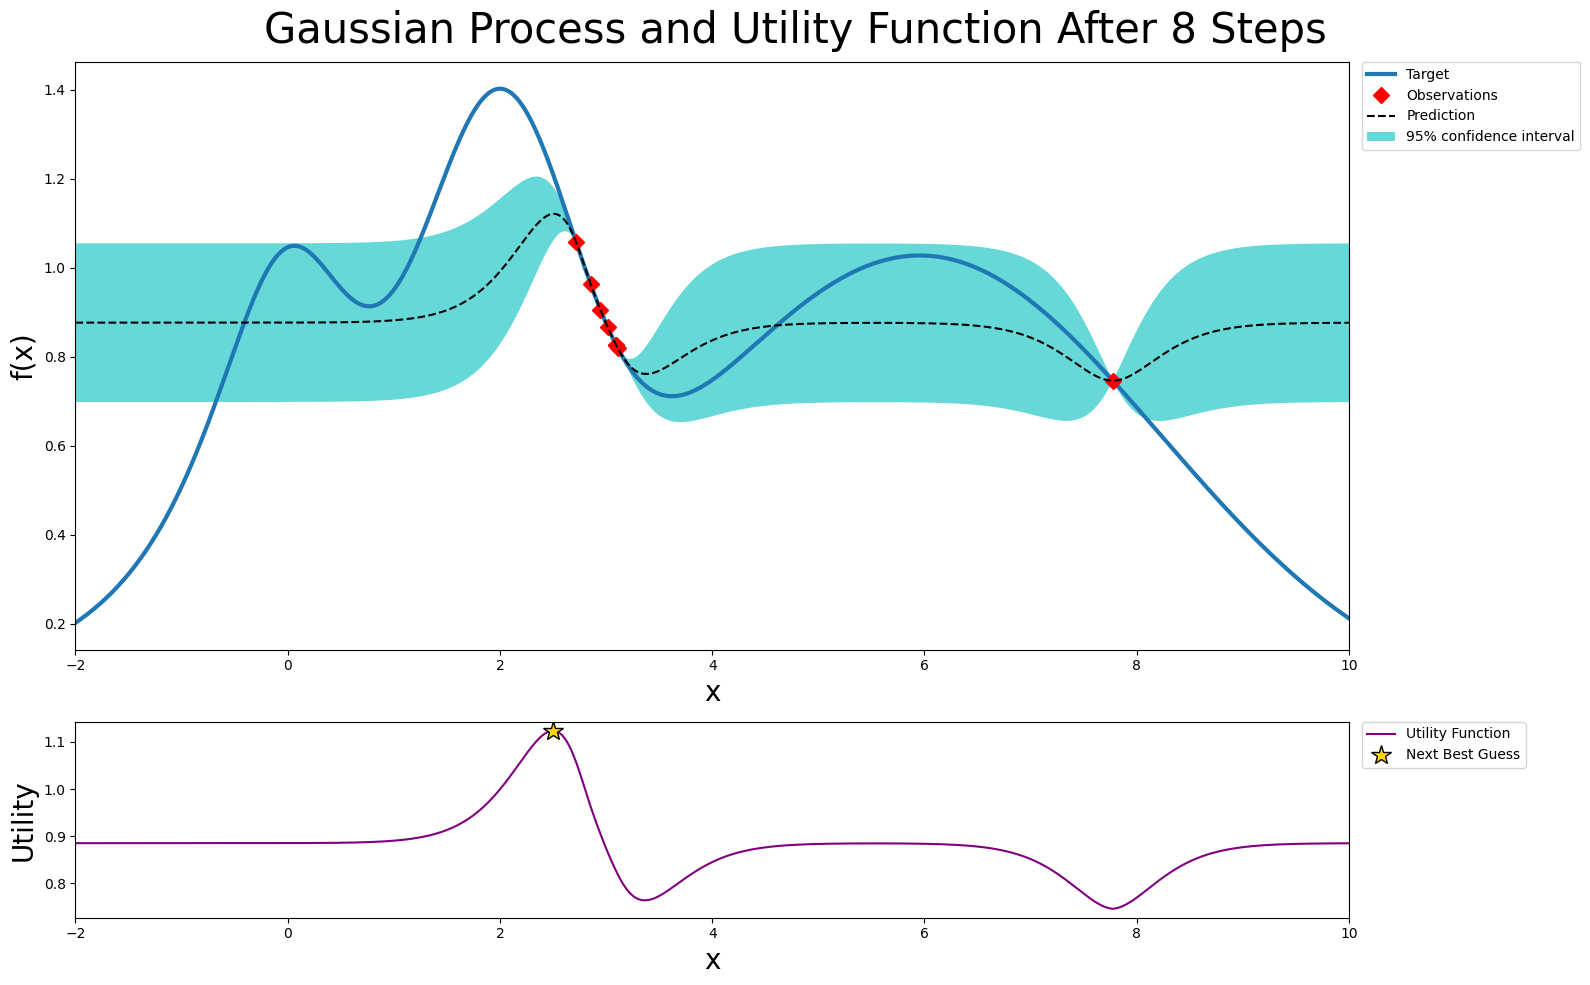

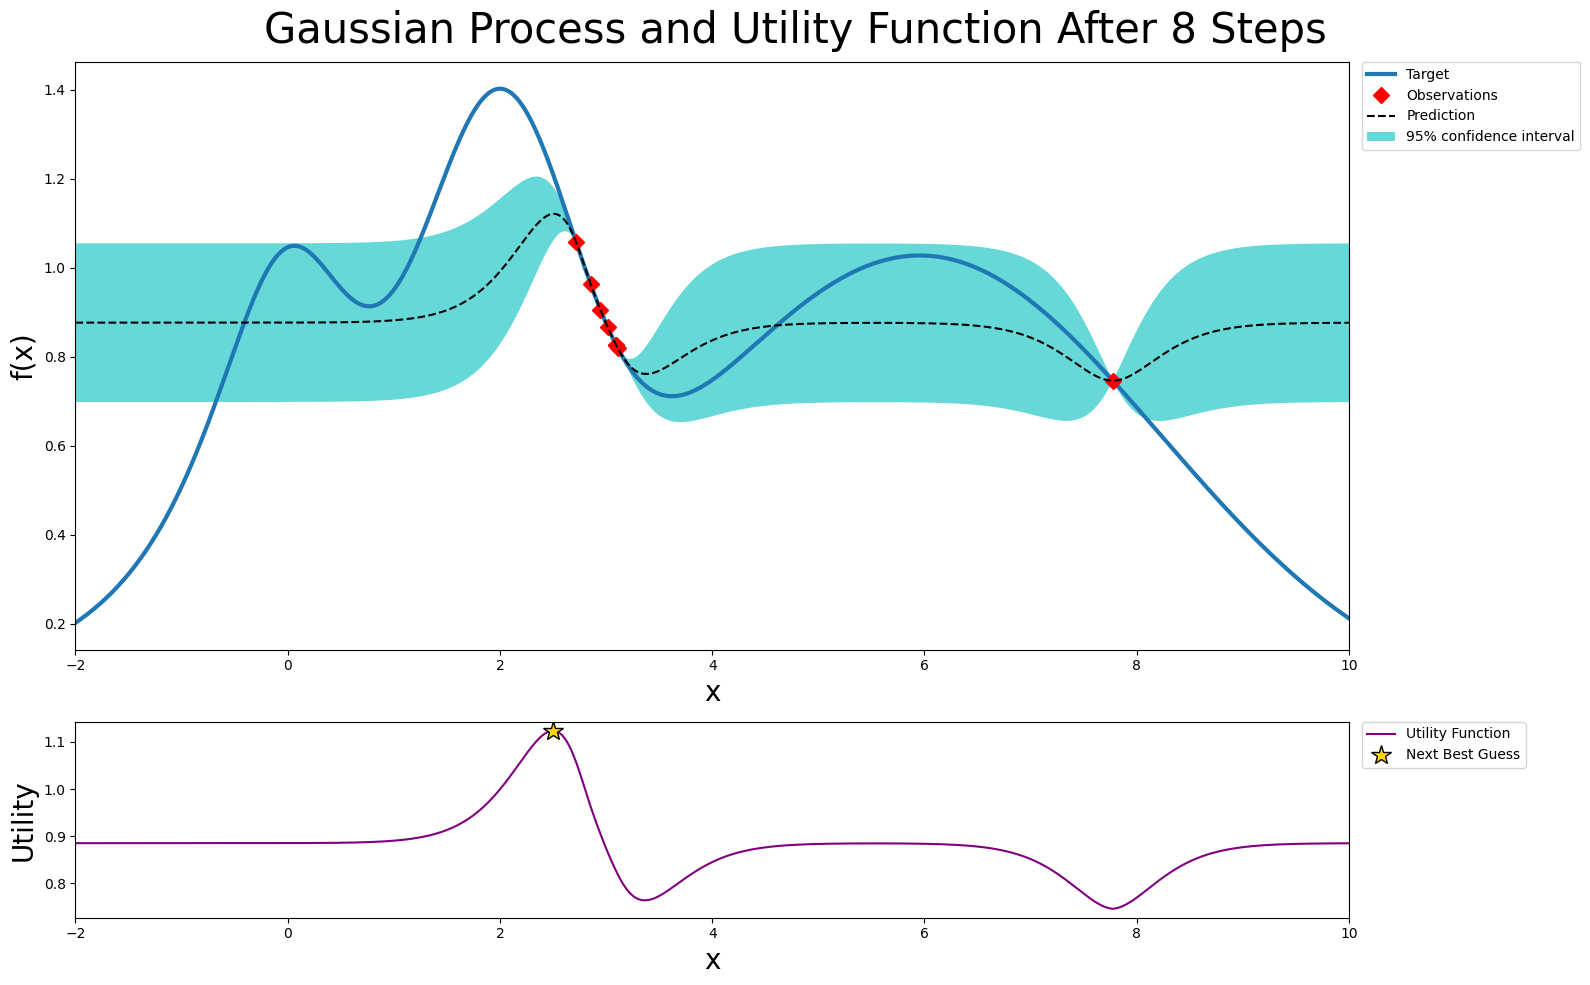

In [ ]:
balanced_ucb = acquisition.UpperConfidenceBound(kappa=2.5)
balanced_optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=balanced_ucb,
    random_state=27,
)

balanced_optimizer_ucb.maximize(init_points=2, n_iter=6)
print("\nUCB Acquisition Function Results:")
plot_gp(balanced_optimizer_ucb, x, y)

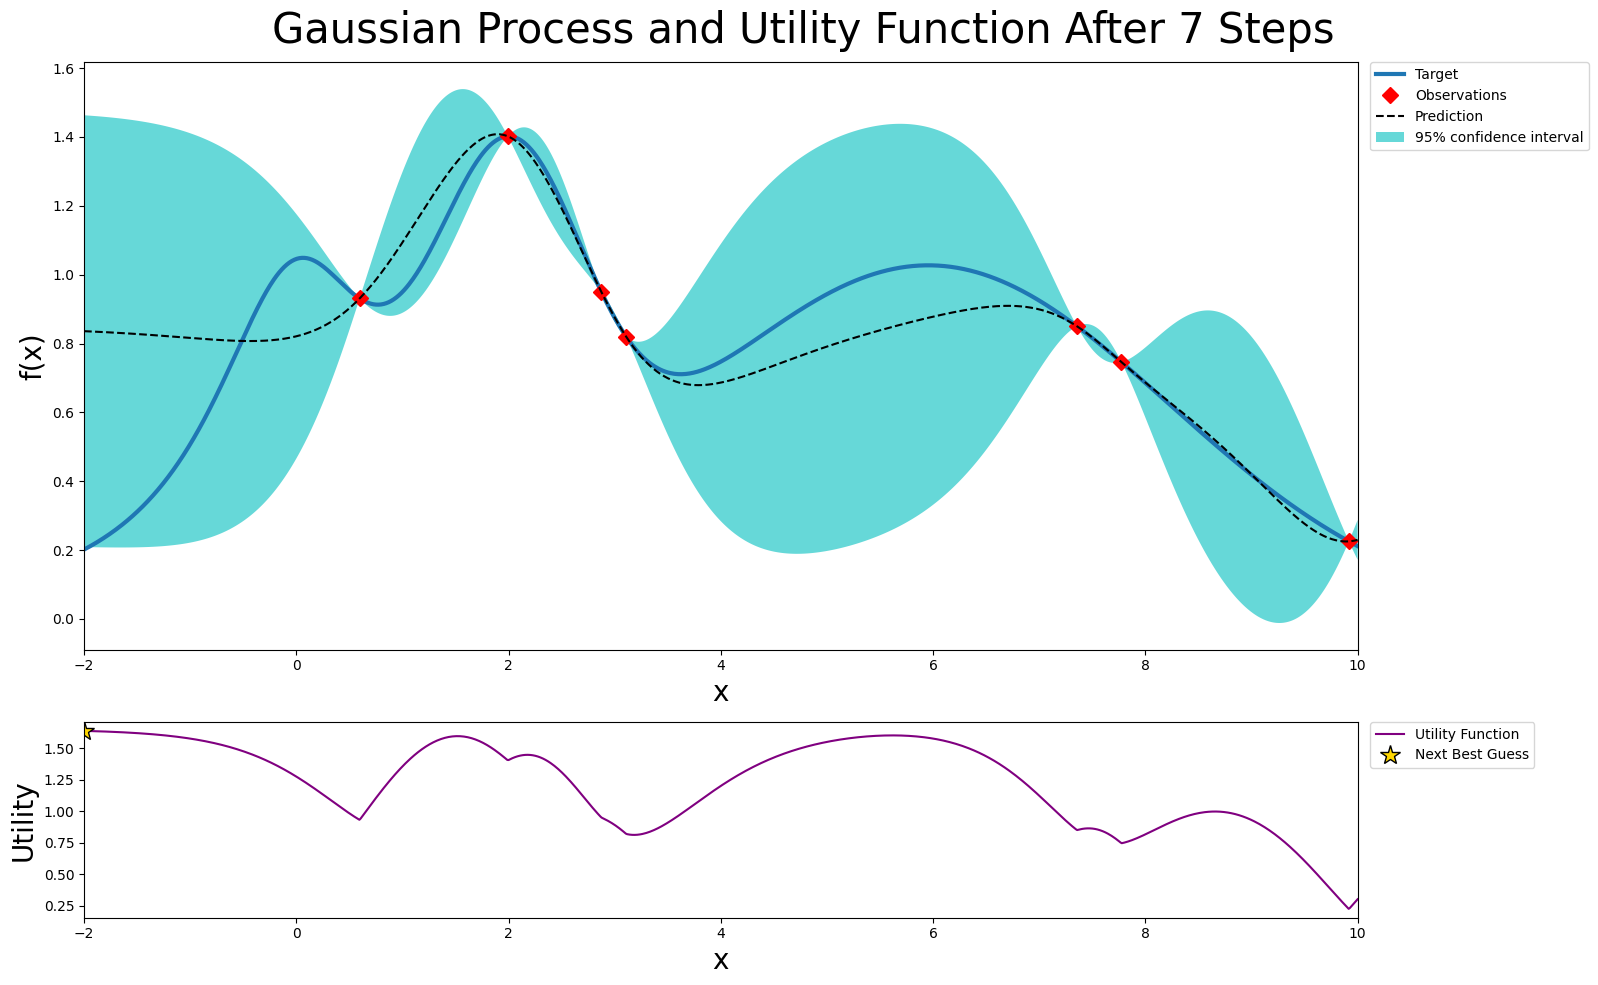

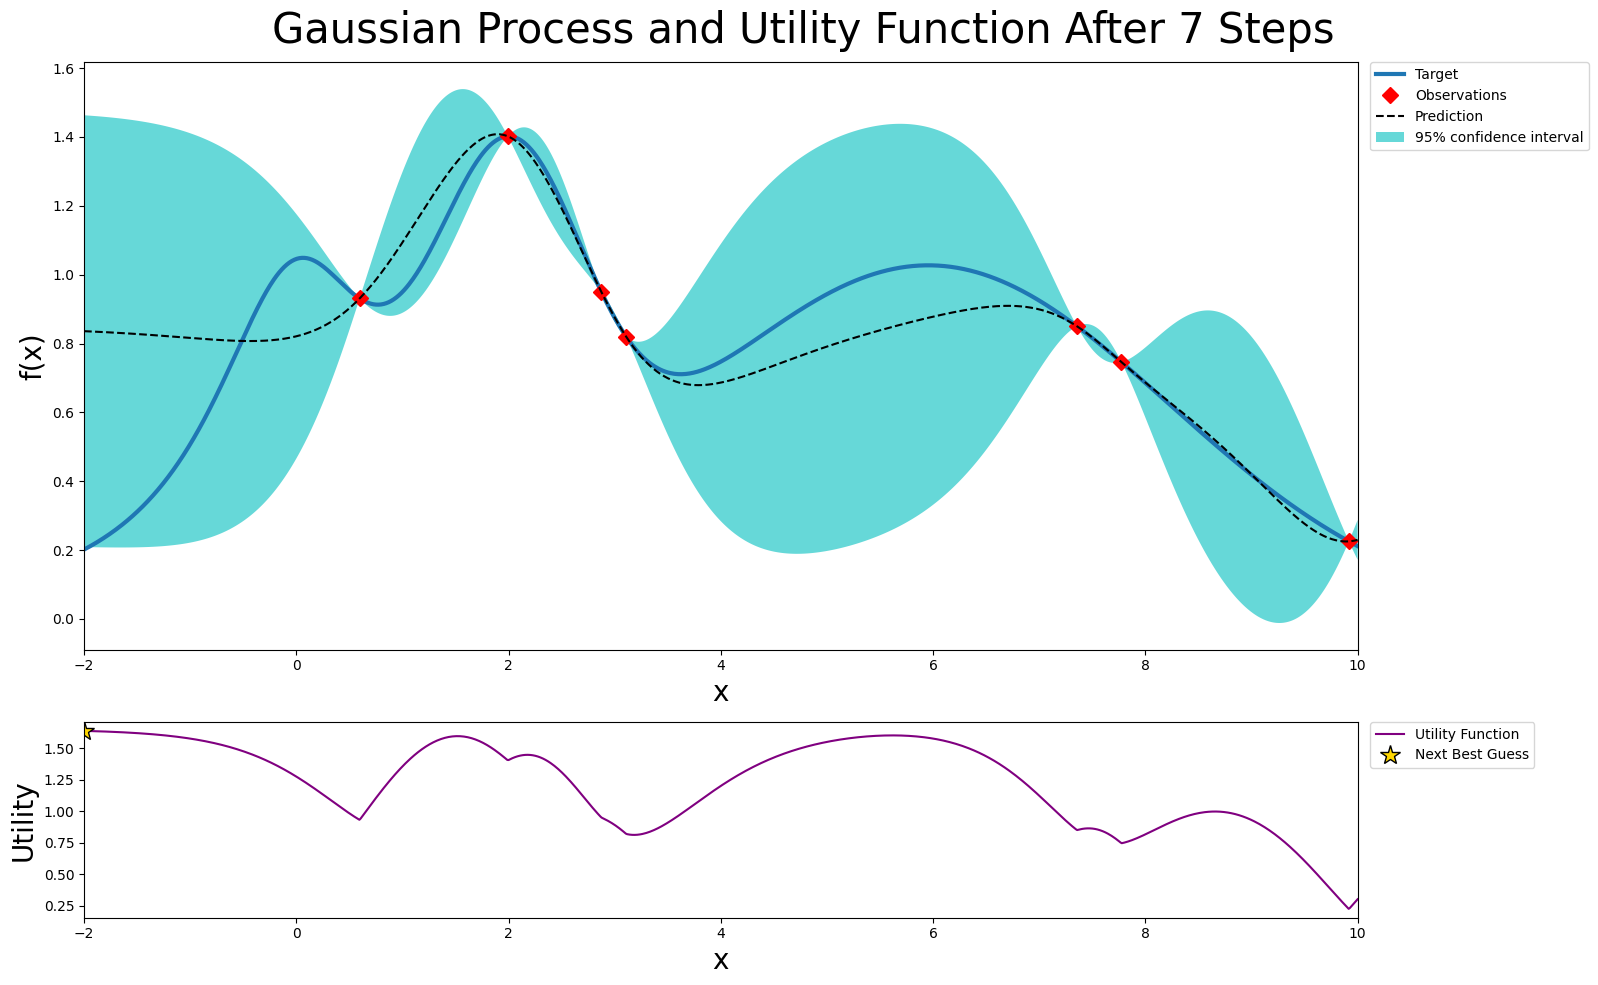

In [ ]:
explore_ucb = acquisition.UpperConfidenceBound(kappa=5)
explore_optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

explore_optimizer_ucb.maximize(init_points=2, n_iter=5)
print("\nUCB Acquisition Function Results:")
plot_gp(explore_optimizer_ucb, x, y)

## Exercise 2: Chaotic Acquisition Function

**Goal**: Implement a chaotic acquisition function that exclusively prioritizes the standard deviation of predictions, disregarding the predicted mean. Compare its performance against standard acquisition functions such as UCB and PI (Probability of Improvement).


In [24]:
class ChaoticAcquisition(acquisition.AcquisitionFunction):
    """Purely explorative acquisition function (only considers std)"""

    def __init__(self, random_state=None):
        super().__init__(random_state)

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        return std  # disregard mean

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8198    | 3.109     |
| 2         | 0.746     | 7.775     |
| 3         | 0.9486    | 2.876     |
| 4         | 1.258     | 1.566     |
| 5         | 1.402     | 2.017     |
| 6         | 0.2021    | -1.997    |
| 7         | 0.212     | 9.999     |

UCB Acquisition Function Results:


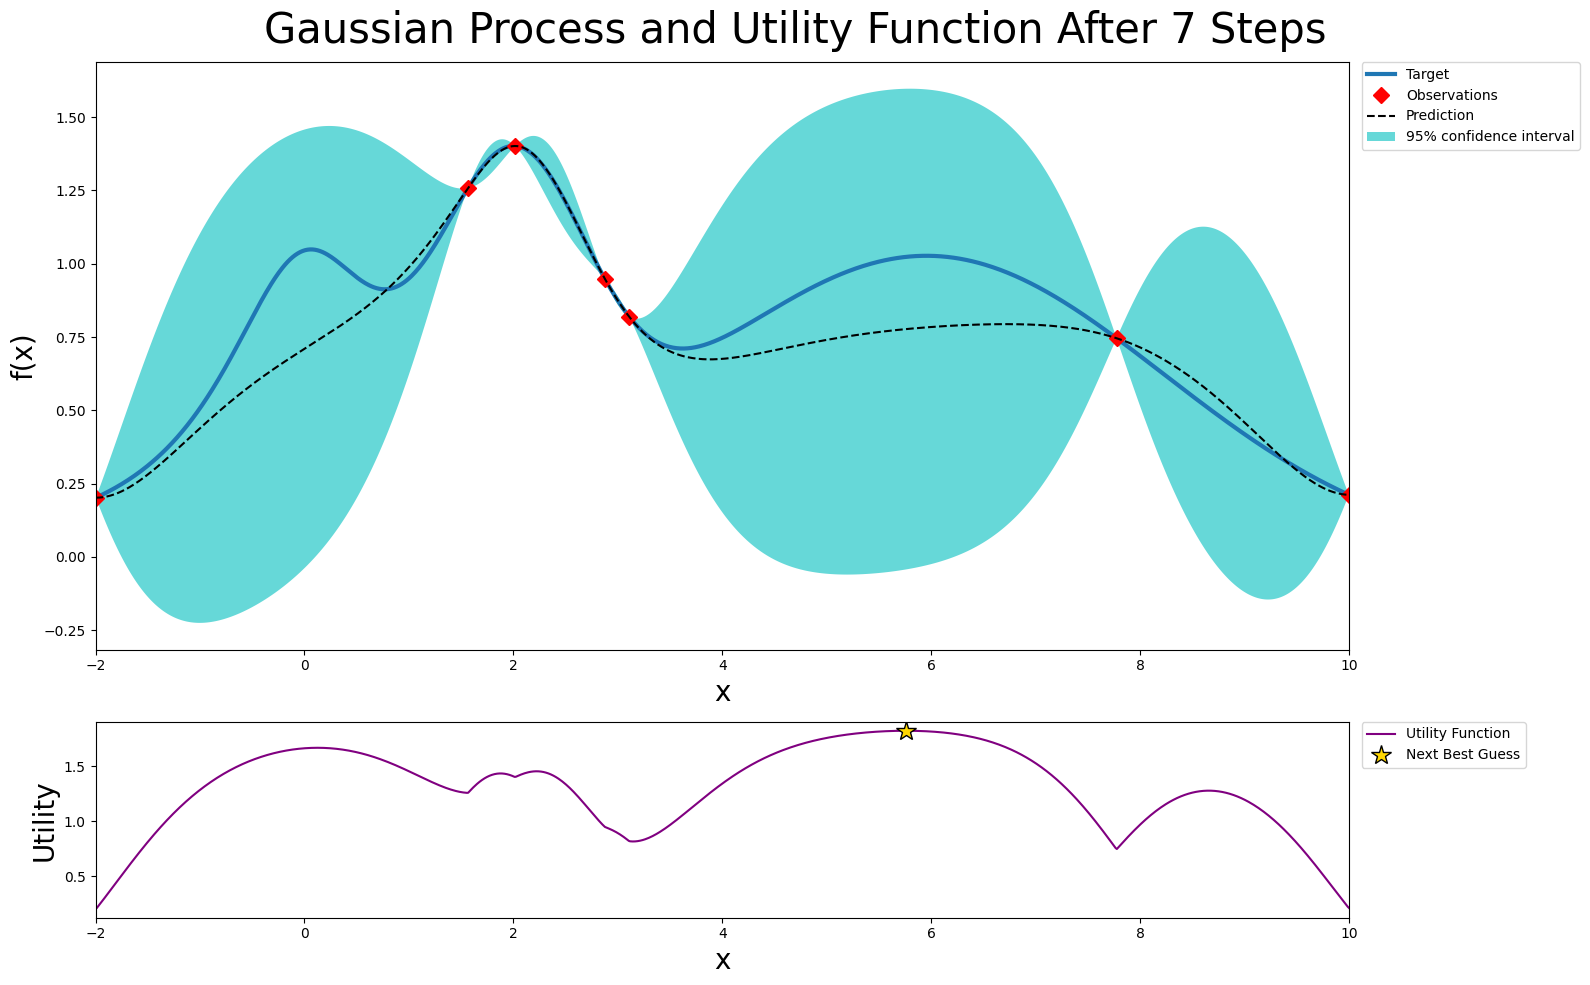

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8198    | 3.109     |
| 2         | 0.746     | 7.775     |
| 3         | 0.8152    | 3.119     |
| 4         | 0.8198    | 3.109     |
| 5         | 0.8213    | 3.105     |
| 6         | 0.8279    | 3.091     |
| 7         | 0.8297    | 3.087     |

Probability of Improvement Acquisition Function Results:


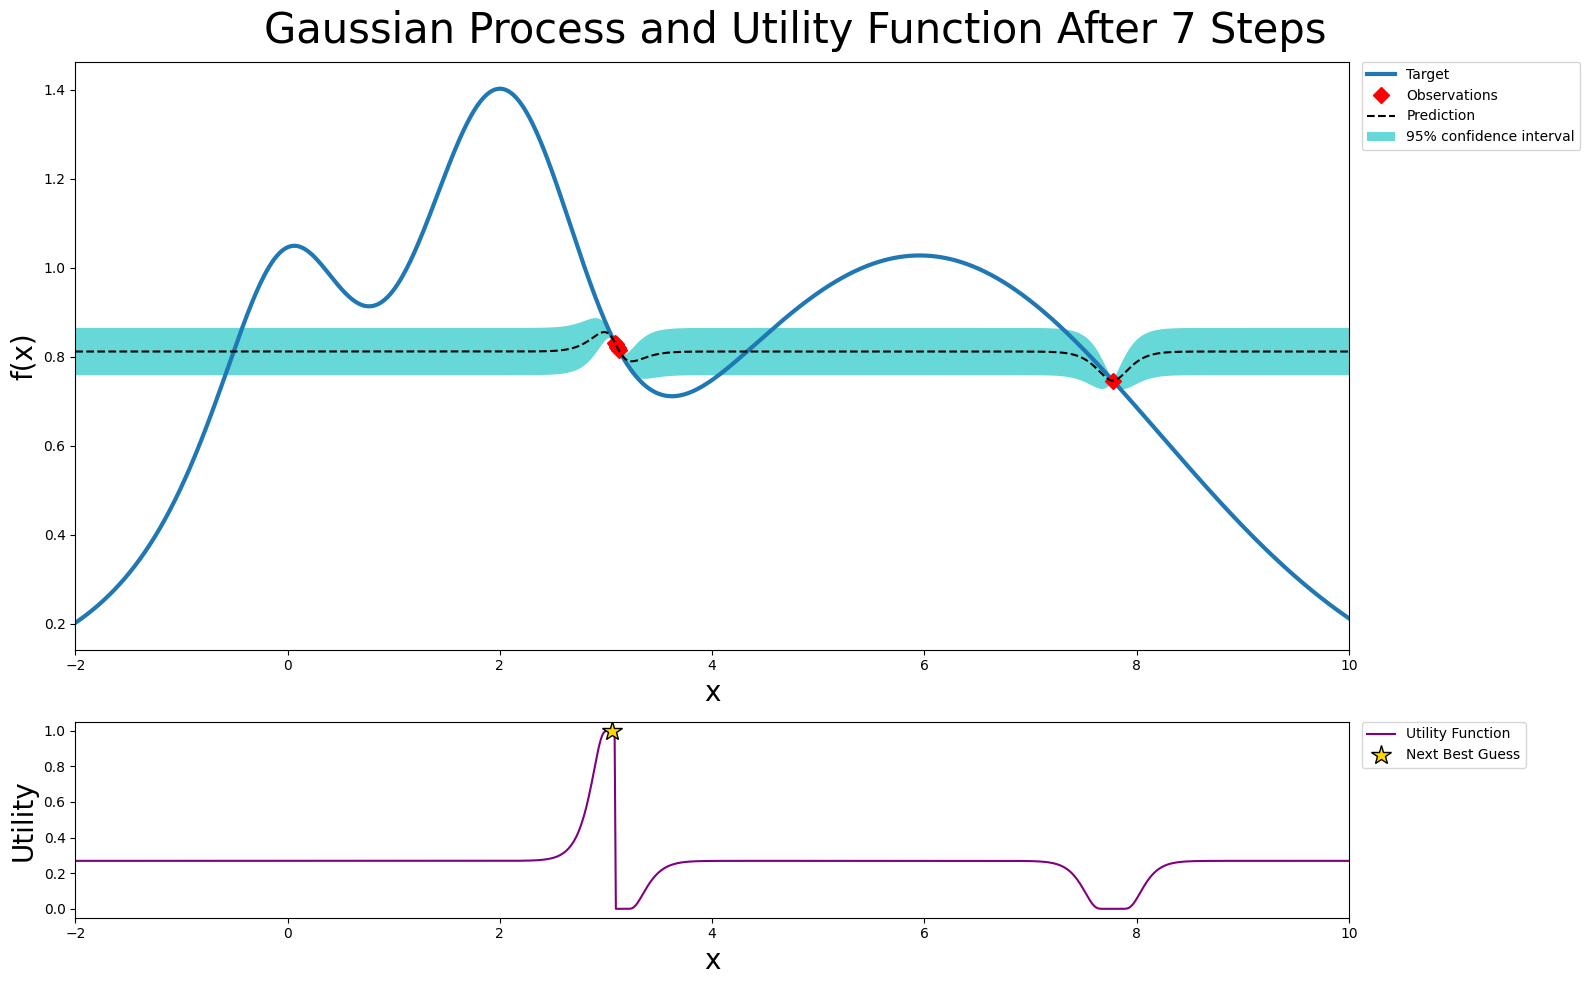

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8198    | 3.109     |
| 2         | 0.746     | 7.775     |
| 3         | 0.2305    | -1.838    |
| 4         | 0.9672    | 1.049     |
| 5         | 0.212     | 9.998     |
| 6         | 1.002     | 5.442     |
| 7         | 0.8832    | -0.3979   |

Chaotic (Purely Explorative) Acquisition Function Results:


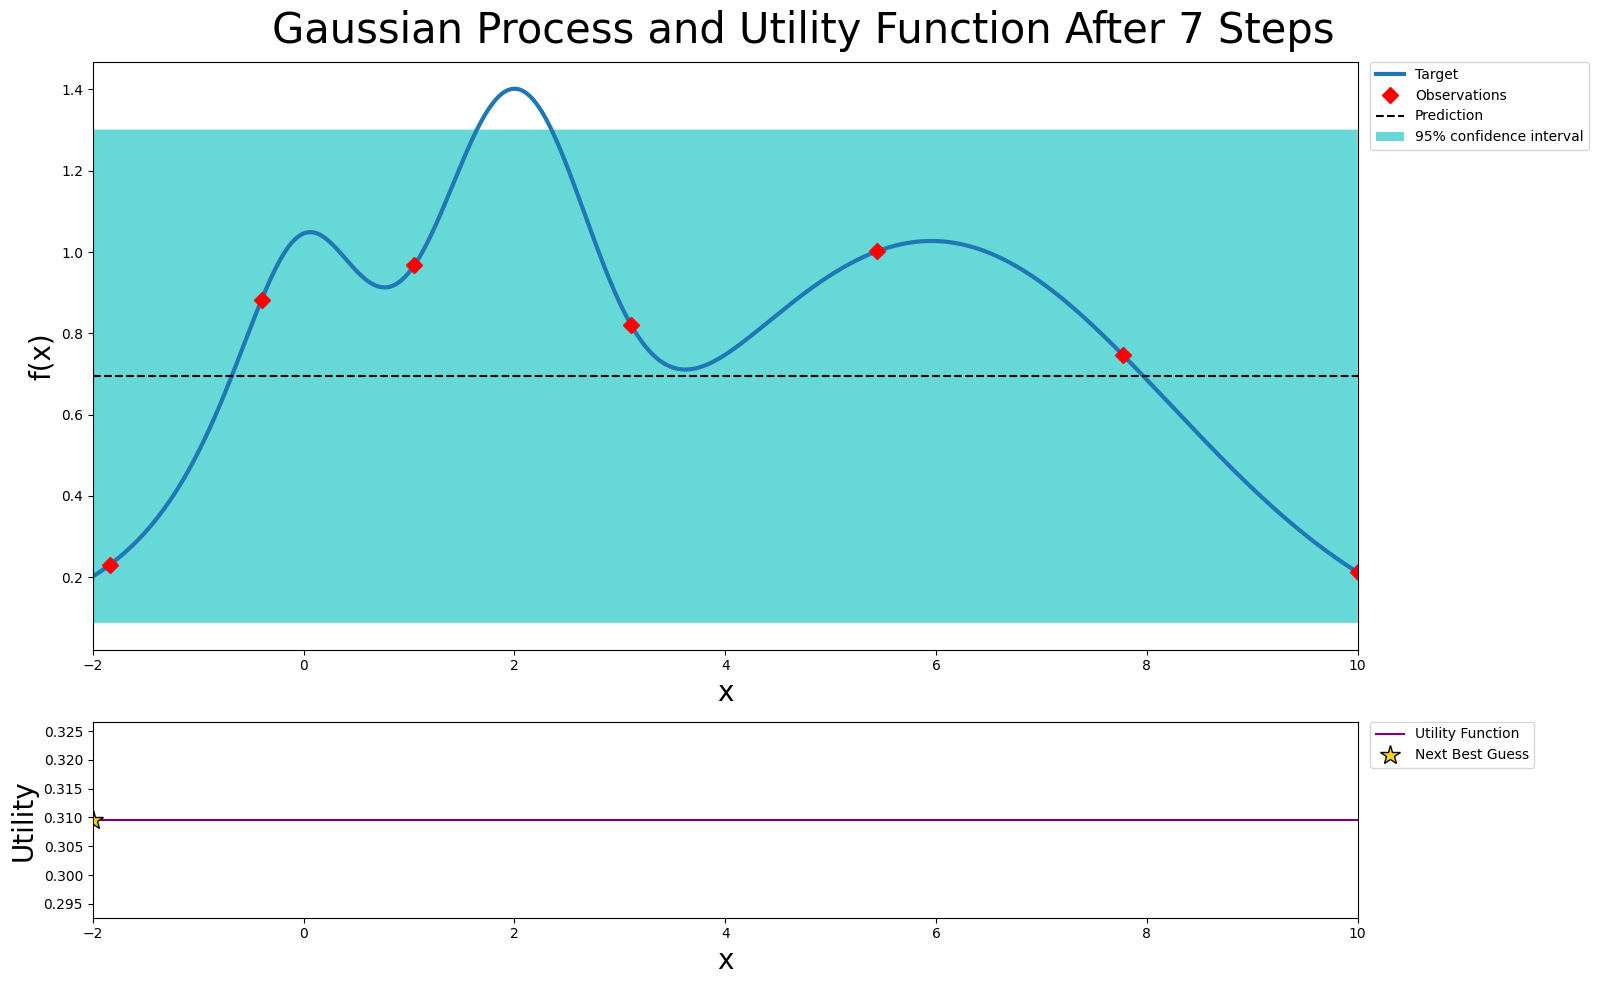


Summary of results:
UCB best value: 1.4017 at x = 2.0170
PI best value: 0.8297 at x = 3.0873
Chaotic best value: 1.0020 at x = 5.4420


In [25]:
ucb = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

optimizer_ucb.maximize(init_points=2, n_iter=5)
print("\nUCB Acquisition Function Results:")
plot_gp(optimizer_ucb, x, y)

# Run with PI
pi = acquisition.ProbabilityOfImprovement(xi=1e-4)
optimizer_pi = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=pi,
    random_state=27,
)

optimizer_pi.maximize(init_points=2, n_iter=5)
print("\nProbability of Improvement Acquisition Function Results:")
plot_gp(optimizer_pi, x, y)

# Run with Chaotic
chaotic = ChaoticAcquisition()
optimizer_chaotic = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=chaotic,
    random_state=27,
)

optimizer_chaotic.maximize(init_points=2, n_iter=5)
print("\nChaotic (Purely Explorative) Acquisition Function Results:")
plot_gp(optimizer_chaotic, x, y)

# Summary
print("\nSummary of results:")
print(
    f"UCB best value: {optimizer_ucb.max['target']:.4f} at x = {optimizer_ucb.max['params']['x']:.4f}"
)
print(
    f"PI best value: {optimizer_pi.max['target']:.4f} at x = {optimizer_pi.max['params']['x']:.4f}"
)
print(
    f"Chaotic best value: {optimizer_chaotic.max['target']:.4f} at x = {optimizer_chaotic.max['params']['x']:.4f}"
)

## Exercise 3: Expected Improvement

**Goal:** Implement the Expected Improvement (EI) acquisition function by extending the `AcquisitionFunction` base class provided by the `BayesOpt` library.

Expected Improvement (EI) is a popular choice for the acquisition function. Let's understand its derivation:

1.  **Current Best:** After $n$ evaluations, the best function value observed _so far_ is $f^* = \max_{m=1..n} f(x_m)$.

2.  **Potential Improvement:** If we evaluate a new point $x$, the _actual_ improvement over the current best $f^*$ is $\max(f(x) - f^*, 0)$, sometimes written as $[f(x) - f^*]^+$.

3.  **The Challenge:** We want to choose $x$ to maximize this improvement, but $f(x)$ is unknown _before_ evaluation.

4.  **The Solution: Expected Improvement:** Our probabilistic model gives a posterior distribution for $f(x)$ at any point $x$. Given the data, this is typically a Gaussian distribution: $f(x) \sim \mathcal{N}(\mu_n(x), \sigma_n^2(x))$. EI maximizes the _expected_ value of the improvement, where the expectation is taken over this posterior distribution:

    $EI_n(x) = E_n[ \max(f(x) - f^*, 0) ]$

    This value represents, on average, how much we expect to improve upon $f^*$ by evaluating at $x$. The next point chosen is the one that maximizes $EI_n(x)$.

### Mathematical Formulation

The expected improvement integral can be computed analytically. The standard closed-form expression is:

$$
EI(x) =
\begin{cases}
(\mu(x) - f^*) \Phi(Z) + \sigma(x) \varphi(Z) & \text{if } \sigma(x) > 0 \\
0 & \text{if } \sigma(x) = 0
\end{cases}
$$

Where:

- $\mu(x)$: The posterior mean of $f(x)$ at point $x$.
- $\sigma(x)$: The posterior standard deviation of $f(x)$ at point $x$.
- $f^*$: The best function value observed so far (a single scalar value).
- $Z = \frac{\mu(x) - f^*}{\sigma(x)}$
- $\Phi(Z)$: The Cumulative Distribution Function (CDF) of the standard normal distribution $\mathcal{N}(0, 1)$.
- $\varphi(Z)$: The Probability Density Function (PDF) of the standard normal distribution $\mathcal{N}(0, 1)$.

### Implementation Task

Create a class `ExpectedImprovement` inheriting from `acquisition.AcquisitionFunction` and implement the core calculation in the `base_acq` method. The signature of `base_acq` method looks like this:

```python
def base_acq(self, mean: NDArray[Float], std: NDArray[Float]) -> NDArray[Float]:
```

Hint: Utilize the `self.y_max` attribute from the `AcquisitionFunction` class to represent $f^*$.

Compare its performance against other acquisition functions.


In [43]:
from scipy.stats import norm

class EIAcquisition(acquisition.AcquisitionFunction):
    """Purely explorative acquisition function (only considers std)"""

    def __init__(self, random_state=None):
        super().__init__(random_state)
        self.y_max = 0

    def base_acq(self, mean: np.ndarray, std: np.ndarray) -> np.ndarray:
        if np.sum(std) == 0:
            return 0
        else:
            Z = (mean - self.y_max)/std
            ei = (mean - self.y_max)*norm.cdf(Z) + std*norm.pdf(Z)
            self.y_max = max(self.y_max - np.sum(ei), 0)
            return ei

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8198    | 3.109     |
| 2         | 0.746     | 7.775     |
| 3         | 0.7406    | 3.342     |
| 4         | 0.2325    | -1.828    |
| 5         | 1.398     | 1.937     |
| 6         | 0.9376    | 0.9575    |
| 7         | 0.2124    | 9.996     |

UCB Acquisition Function Results:


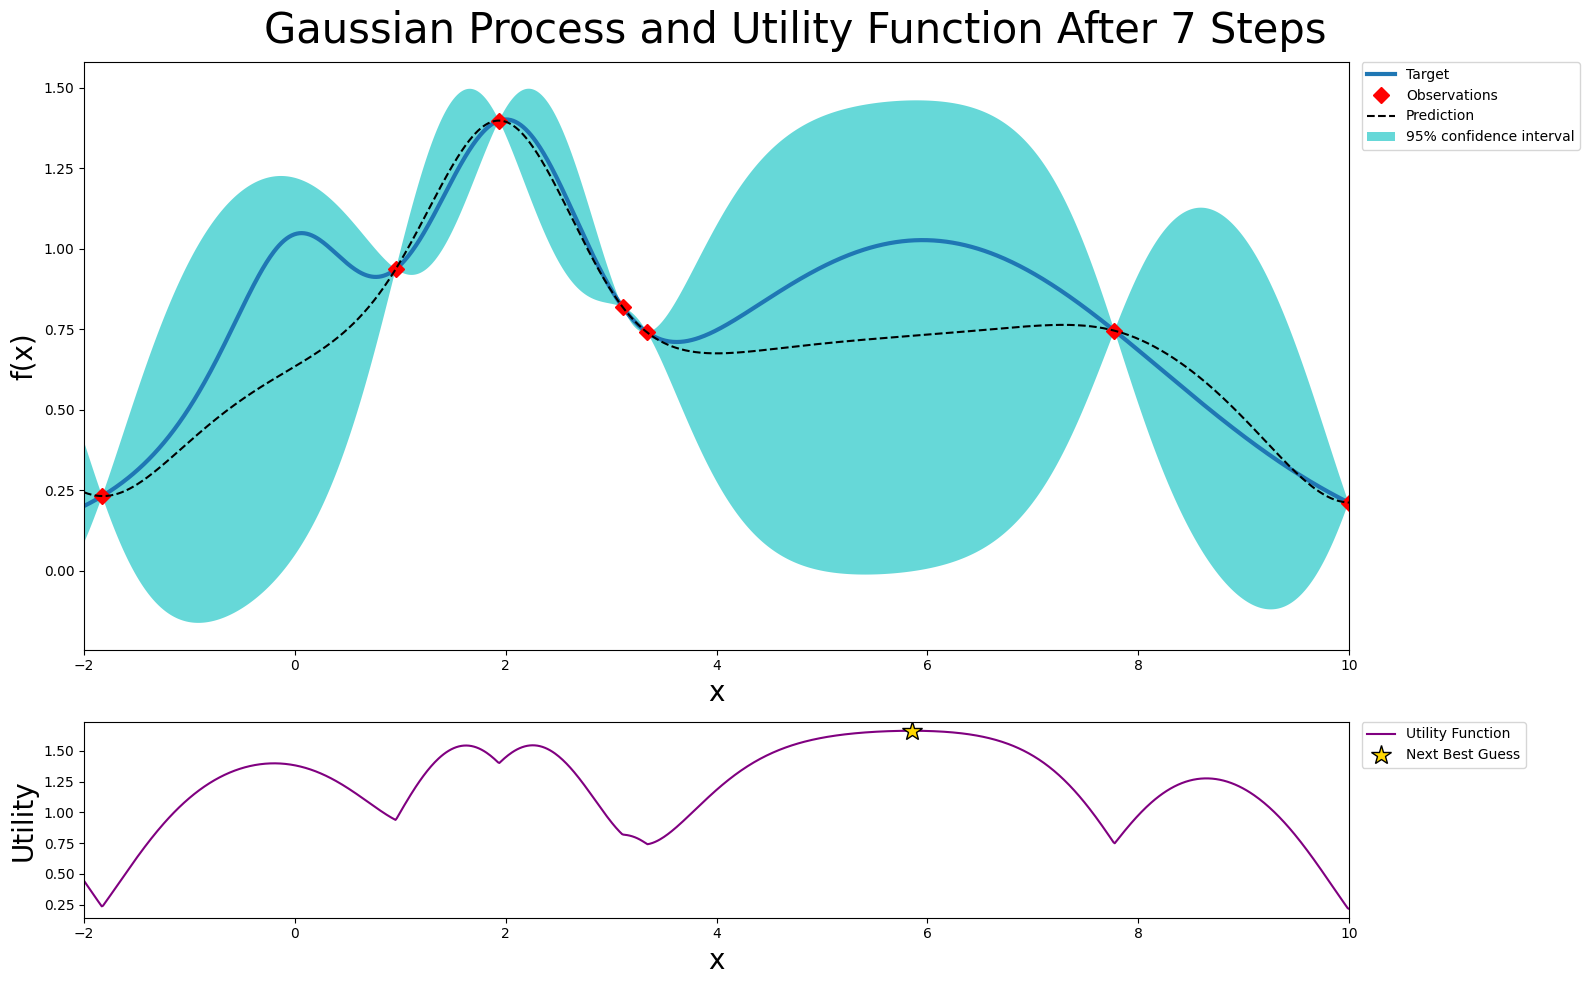

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8198    | 3.109     |
| 2         | 0.746     | 7.775     |
| 3         | 0.8152    | 3.119     |
| 4         | 0.8194    | 3.109     |
| 5         | 0.8216    | 3.105     |
| 6         | 0.8242    | 3.099     |
| 7         | 0.8323    | 3.082     |

Probability of Improvement Acquisition Function Results:


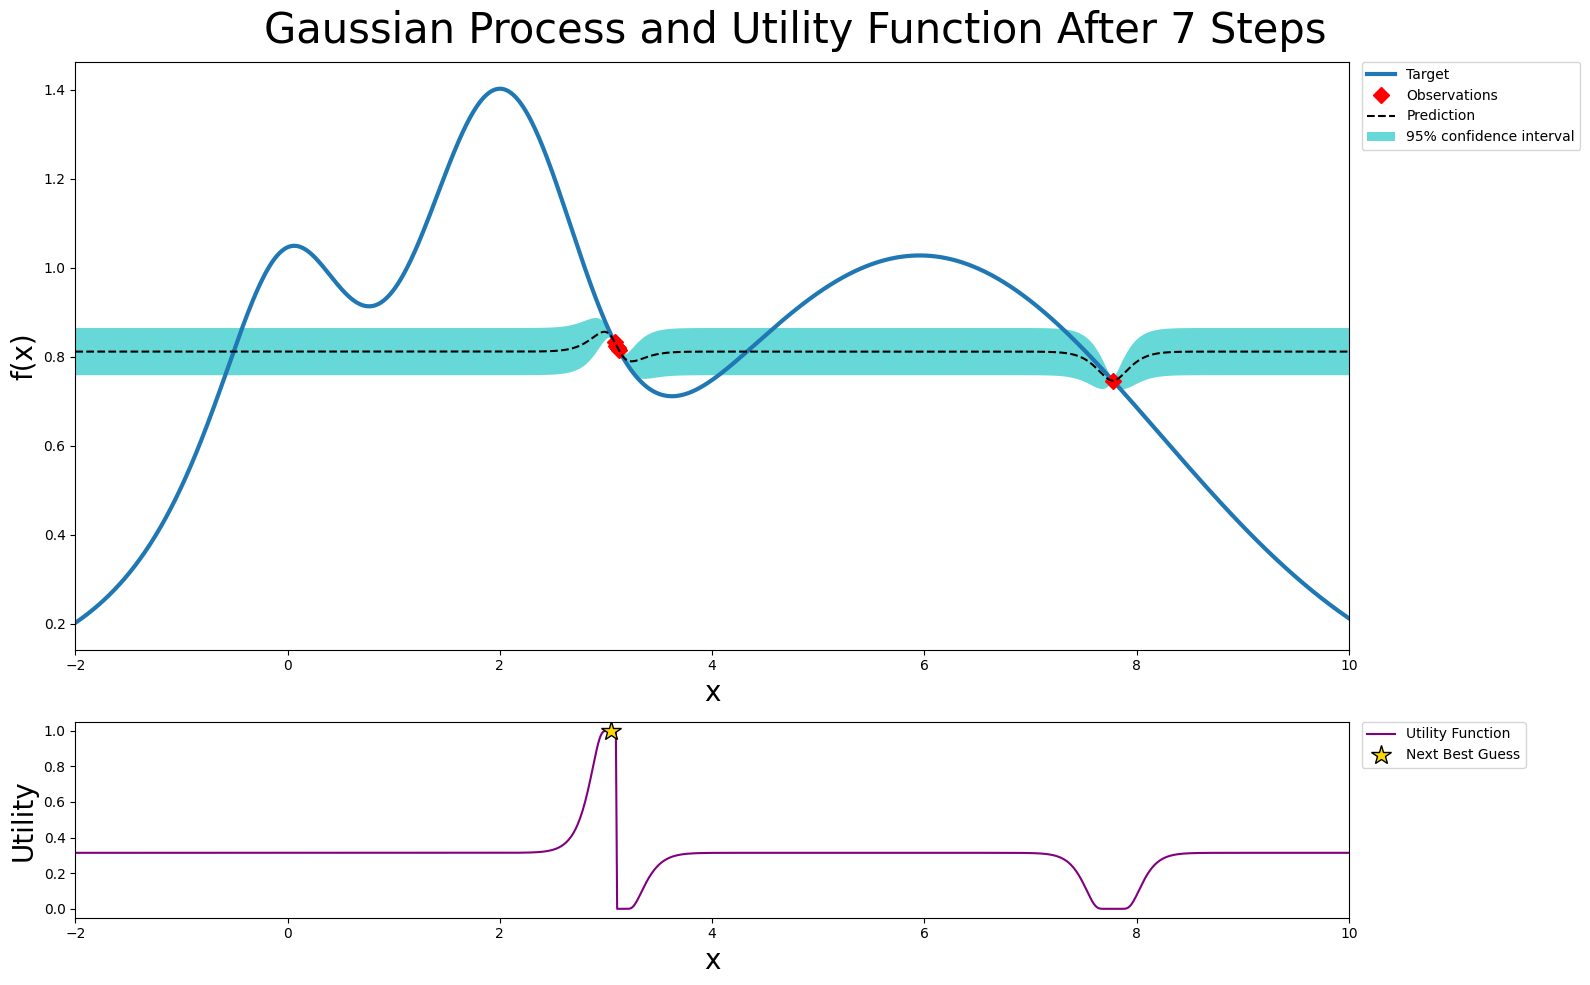

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 0.8198    | 3.109     |
| 2         | 0.746     | 7.775     |
| 3         | 0.8198    | 3.109     |
| 4         | 0.8622    | 3.023     |
| 5         | 0.876     | 2.997     |
| 6         | 0.917     | 2.927     |
| 7         | 0.9789    | 2.83      |

Estimated Improvement Acquisition Function Results:


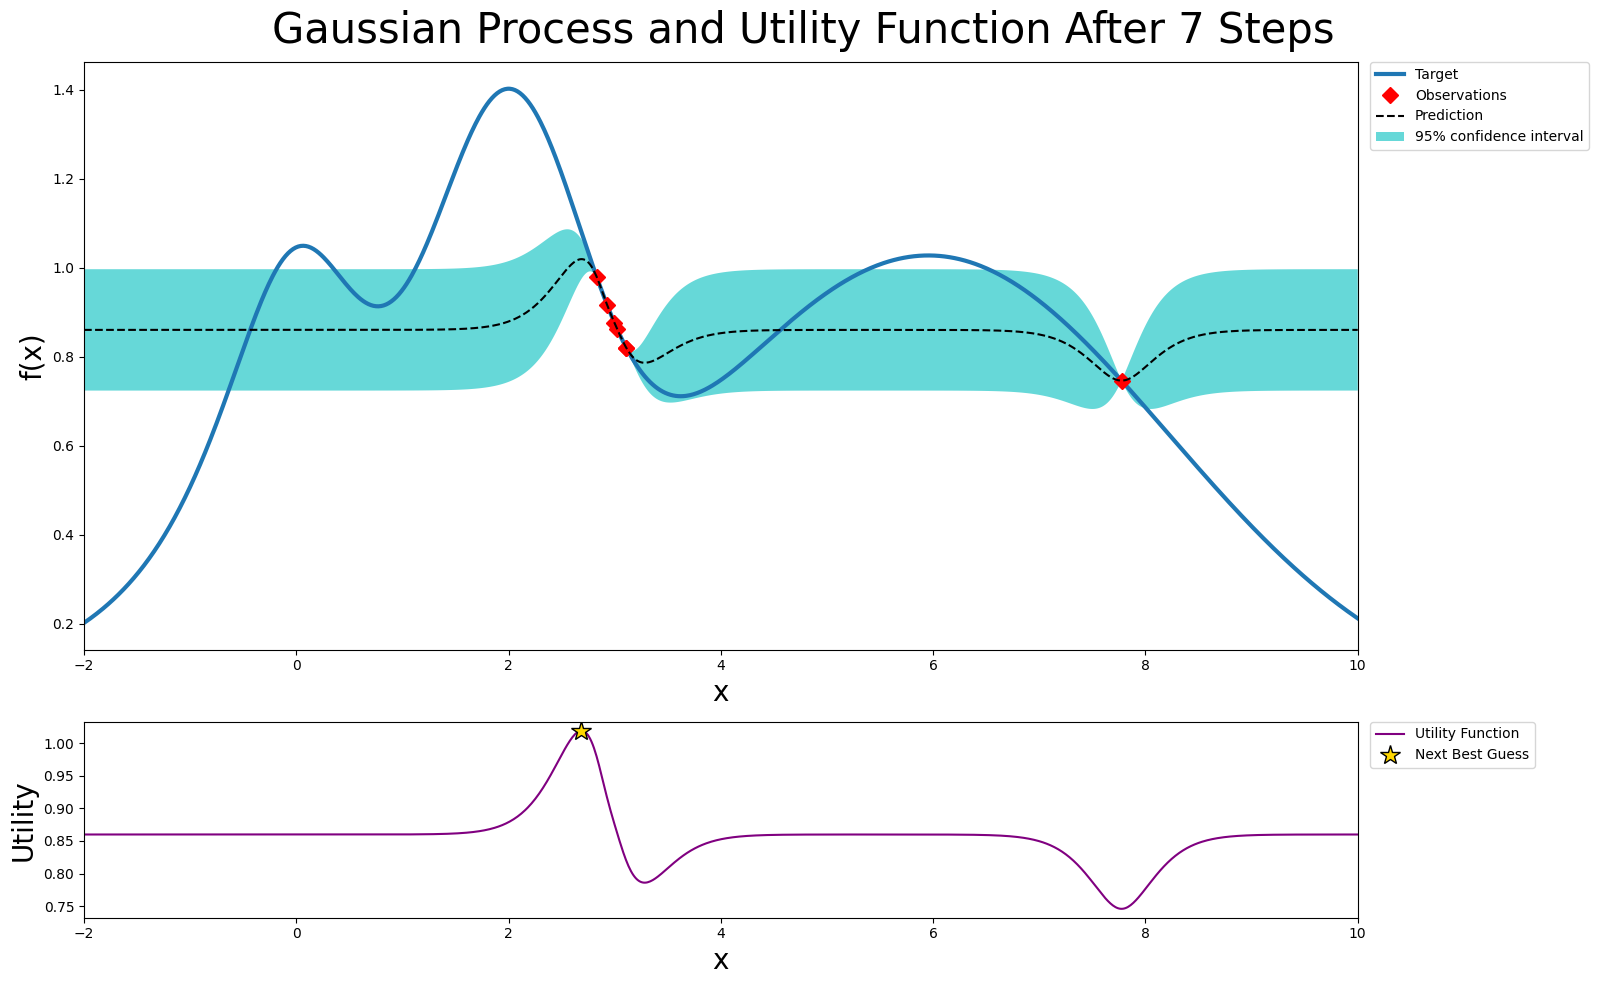


Summary of results:
UCB best value: 1.3984 at x = 1.9369
PI best value: 0.8323 at x = 3.0818
Chaotic best value: 0.9789 at x = 2.8304


In [44]:
ucb = acquisition.UpperConfidenceBound(kappa=2.5)
optimizer_ucb = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ucb,
    random_state=27,
)

optimizer_ucb.maximize(init_points=2, n_iter=5)
print("\nUCB Acquisition Function Results:")
plot_gp(optimizer_ucb, x, y)

# Run with PI
pi = acquisition.ProbabilityOfImprovement(xi=1e-4)
optimizer_pi = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=pi,
    random_state=27,
)

optimizer_pi.maximize(init_points=2, n_iter=5)
print("\nProbability of Improvement Acquisition Function Results:")
plot_gp(optimizer_pi, x, y)

# Run with Estimated Improvement
ei = EIAcquisition()
optimizer_ei = BayesianOptimization(
    f=target_function,
    pbounds={"x": (-2, 10)},
    acquisition_function=ei,
    random_state=27,
)

optimizer_ei.maximize(init_points=2, n_iter=5)
print("\nEstimated Improvement Acquisition Function Results:")
plot_gp(optimizer_ei, x, y)

# Summary
print("\nSummary of results:")
print(
    f"UCB best value: {optimizer_ucb.max['target']:.4f} at x = {optimizer_ucb.max['params']['x']:.4f}"
)
print(
    f"PI best value: {optimizer_pi.max['target']:.4f} at x = {optimizer_pi.max['params']['x']:.4f}"
)
print(
    f"Chaotic best value: {optimizer_ei.max['target']:.4f} at x = {optimizer_ei.max['params']['x']:.4f}"
)

Expected Improvement certaily did better than the Probability of Improvement. <br>
Probability of Improvement sampled points only around the 2 initial points and didn't explore new area at all, not making progress towards fitting to the target line. <br><br>

Estimated Improvement did little of exploration 'climbing' towards the hill before the first initial point.<br><br>

Upper Confidence Bound did best job, exploring the widest range of space and after the first 7 steps, fits the target function the most

## Exercise 4: Theoretical Questions

1. Why is Bayesian Optimization particularly useful for expensive-to-evaluate functions?
2. Compare and contrast the different acquisition functions discussed in this tutorial.
3. What are the limitations of Bayesian Optimization?


1. Why is Bayesian Optimization particularly useful for expensive-to-evaluate functions
- Bayesian Optimization is particularly useful for expensive-to-evaluate functions because it efficiently balances exploration and exploitation to find the global optimum with as few function evaluations as possible. The essential ingredients of a BO algorithm are the surrogate model (SM) and the acquisition function (AF). The surrogate model is often a Gaussian Process that can fit the observed data points and quantify the uncertainty of unobserved areas. So, SM is our effort to approximate the unknown black-box function f(x). By finding the x that maximizes the acquisition function, we identify the next best guess for f to try. And maximizing the AF function is much easier and much less expensive
2. Comparison and contrast of differet acquisition functions
-  Upper Confidence Bound (UCB): Balances exploration and exploitation by maximizing the upper confidence bound (mean + uncertainty), with a tunable parameter controlling exploration.

- Expected Improvement (EI): Favors points likely to improve upon the current best value, balancing exploration and exploitation.

- Probability of Improvement (PI): Selects points with the highest probability of improving over the current best, often over-exploits.

- Greedy: Always picks the point with the best predicted mean (ignores uncertainty).
3. Limitations of Bayesian Optimization
- Requires the true objective function to be well modelled by a Gaussian Process
- Empirically has been observed to perform poorly on high dimensional objective functions
- Takes time to converge, may not converge at all. Gradient Methods like SGD may be faster
- Is designed for continuous problems, not descrete
- Other methods often outperform BO, in scenarios other than when the function is expensive to evaluate or non-differentiable